<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>BHs in Binaries</p>
    <o style='font-size:20px;'>This notebook explores how BHs in binaries are different from the isolated population</p>
</div>

In [1]:
import cogsworth
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload
import warnings
import os

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [2]:
files = ["fiducial"]
labels = ["Fiducial"]
colours = ["#333"]

pops, data = helpers.load_postprocessed_pops(files, labels, colours)

Loading post-processed data for Fiducial from fiducial


In [3]:
if os.path.exists("/mnt/ceph/users/twagg/underworld/sims/fiducial/fiducial_co_star.h5"):
    co_pop = cogsworth.pop.load("/mnt/ceph/users/twagg/underworld/sims/fiducial/fiducial_co_star.h5")
    co_pop.orbits
    bh_star_pop = co_pop[co_pop.final_bpp["kstar_1"] == 14]
    ns_star_pop = co_pop[co_pop.final_bpp["kstar_1"] == 13]
else:
    with warnings.catch_warnings(category=FutureWarning):
        warnings.simplefilter("ignore")
        co_pops = [cogsworth.pop.load(f"/mnt/ceph/users/twagg/underworld/sims/fiducial/fiducial_co_plus_star_part{i}.h5") for i in range(100)]

    [(pop.final_pos, pop.orbits) for pop in co_pops]
    with warnings.catch_warnings(category=FutureWarning):
        warnings.simplefilter("ignore")
        co_pop = sum(co_pops[1:], start=co_pops[0])

    co_pop.final_pos
    co_pop.orbits
    co_pop.save("/mnt/ceph/users/twagg/underworld/sims/fiducial/fiducial_co_star.h5", overwrite=True)
    bh_star_pop = co_pop[co_pop.final_bpp["kstar_1"] == 14]
    ns_star_pop = co_pop[co_pop.final_bpp["kstar_1"] == 13]

# Mass distribution

In [ ]:
bh_star_pop.final_bpp["mass_1"] > sq

,tphys,mass_1,mass_2,kstar_1,kstar_2,sep,porb,ecc,evol_type,RRLO_1,RRLO_2,massc_he_layer_1,massc_co_layer_1,massc_he_layer_2,massc_co_layer_2,lum_1,lum_2,teff_1,teff_2,SN_1,SN_2,omega_spin_1,omega_spin_2,rad_1,rad_2,bin_num,metallicity
6311,1779.480878,5.629105,1.268522,14,1,39.822686,11.089657,0.113656,10,1.324731e-06,0.139156,0.0,0.0,0.0,0.0,1.000000e-10,5.692762,3752.900103,7922.726609,1,0,200000000.0,0.330880,0.000024,1.277766,6311,0.001735
13374,538.374270,25.740011,1.817678,14,1,6438.203041,11405.064953,0.015238,10,2.845722e-08,0.001309,0.0,0.0,0.0,0.0,1.000000e-10,19.424963,1755.020993,9780.367715,1,0,200000000.0,6341.473179,0.000109,1.548849,13374,0.003224
15102,1910.769259,13.237111,0.121333,14,0,14965.903054,58056.202276,0.199021,10,6.467204e-09,0.000118,0.0,0.0,0.0,0.0,1.000000e-10,0.002568,2447.316198,3487.985880,1,0,200000000.0,388.567117,0.000056,0.140031,15102,0.000419
25048,1678.098242,24.849177,0.244668,14,0,19121.265690,61173.525563,0.079914,10,8.306899e-09,0.000144,0.0,0.0,0.0,0.0,1.000000e-10,0.010720,1786.202431,3678.479455,1,0,200000000.0,0.933438,0.000105,0.257221,25048,0.002878
29747,928.631282,13.711816,1.637282,14,1,21240.770883,91576.942347,0.359967,10,7.583112e-09,0.000536,0.0,0.0,0.0,0.0,1.000000e-10,14.560379,2404.579801,8991.951446,1,0,200000000.0,4747.109112,0.000058,1.586418,29747,0.002840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31487414,10665.040823,24.028399,0.133893,14,0,933.147775,672.092005,0.101762,10,1.635953e-07,0.002240,0.0,0.0,0.0,0.0,1.000000e-10,0.002788,1816.453418,3342.762659,1,0,200000000.0,200.698849,0.000102,0.158835,31487414,0.002891
31496533,10936.418518,21.157237,0.532118,14,0,8718.520632,20258.768232,0.560429,10,3.474987e-08,0.000952,0.0,0.0,0.0,0.0,1.000000e-10,0.065848,1935.785375,4164.886136,1,0,200000000.0,12.323314,0.000090,0.497283,31496533,0.003612
31501311,11140.195992,15.844851,0.364887,14,0,3229.574896,5283.262680,0.633798,10,8.370202e-08,0.002187,0.0,0.0,0.0,0.0,1.000000e-10,0.024151,2236.879600,3901.959267,1,0,200000000.0,136.277766,0.000067,0.343116,31501311,0.001025
31513418,11576.864634,4.578275,0.745483,14,1,13.876464,2.596458,0.254724,10,3.487194e-06,0.327813,0.0,0.0,0.0,0.0,1.000000e-10,0.582542,4161.364475,5642.253867,1,0,200000000.0,1233.909533,0.000019,0.805930,31513418,0.001657


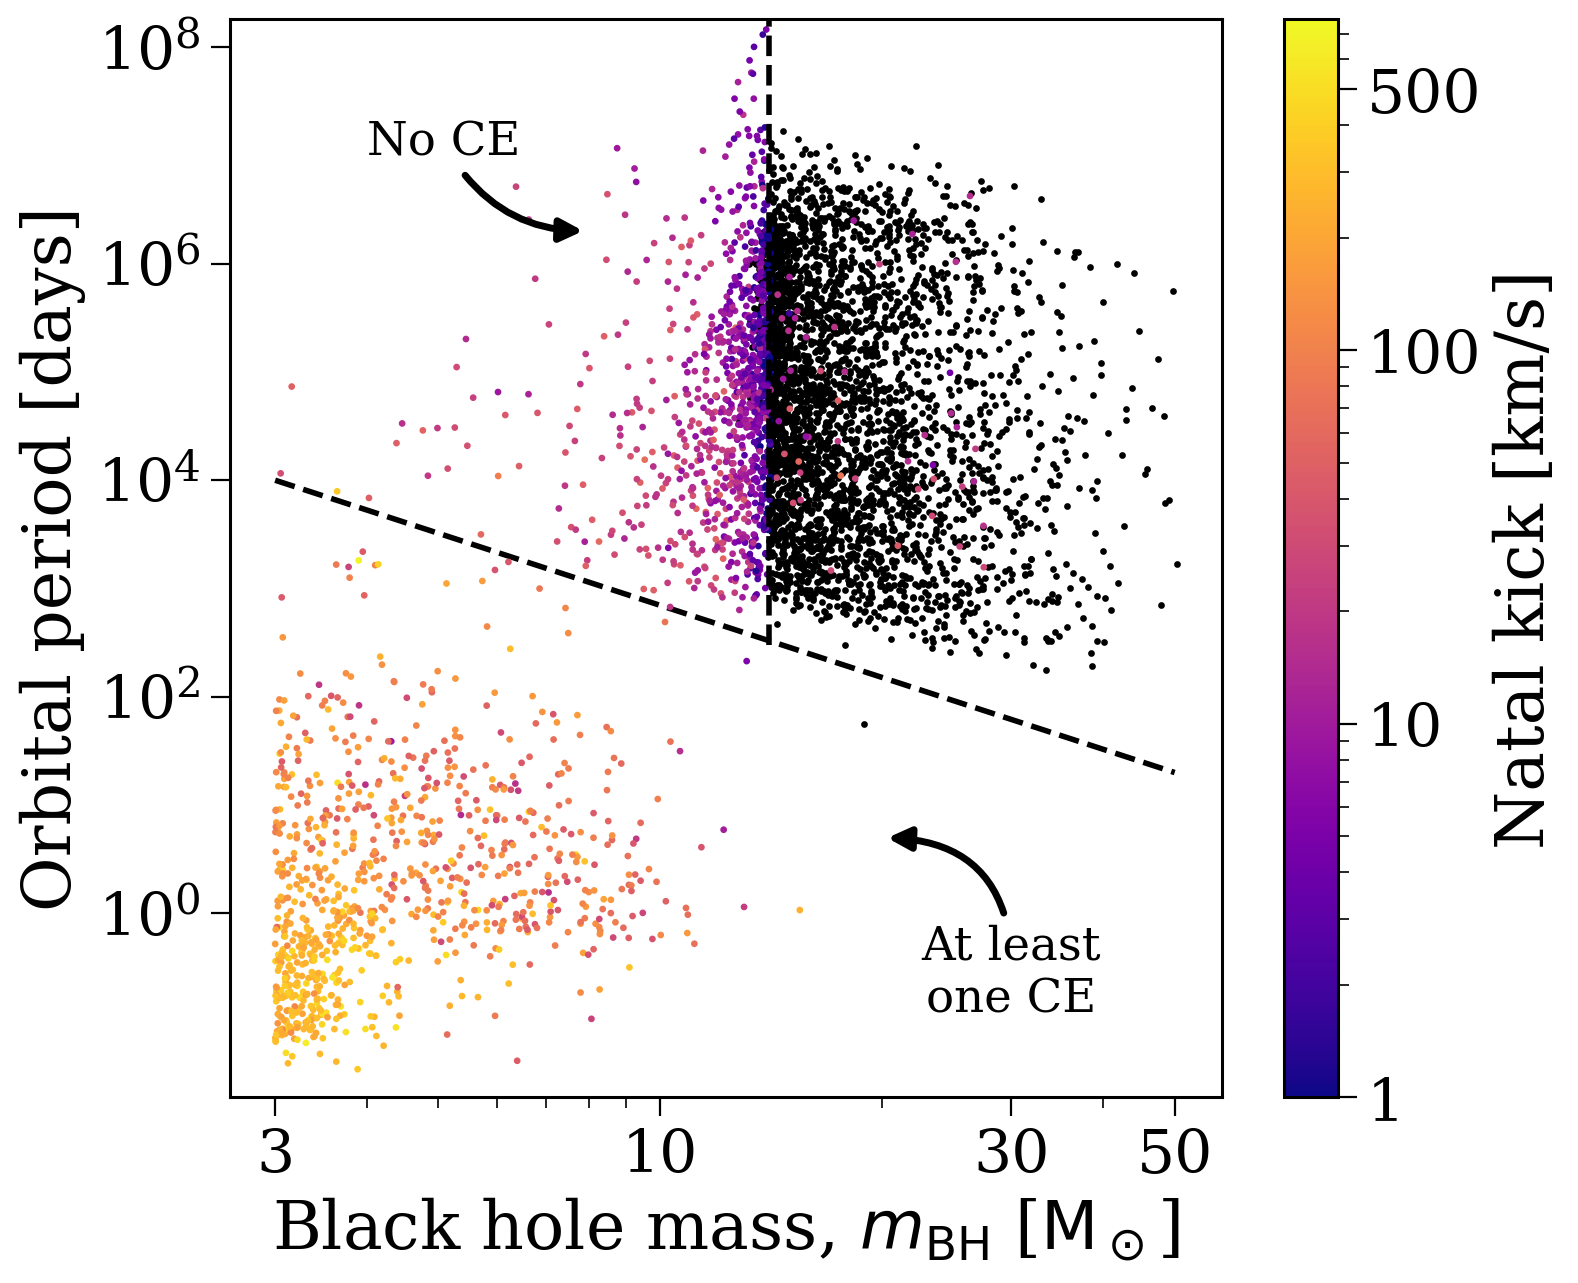

In [27]:
fig, ax = plt.subplots(figsize=(8, 7))

# had_ce = np.isin(bh_star_pop.bin_nums, bh_star_pop.bpp[bh_star_pop.bpp["evol_type"] == 3]["bin_num"])
# plt.scatter(bh_star_pop.final_bpp["mass_1"], bh_star_pop.final_bpp["porb"], c=had_ce, s=5)

kick_strength = bh_star_pop.kick_info[bh_star_pop.kick_info["star"] == 1]["natal_kick"]
got_kicked = kick_strength > 0
ax.scatter(bh_star_pop.final_bpp["mass_1"][~got_kicked], bh_star_pop.final_bpp["porb"][~got_kicked], c='k', s=2, rasterized=True)
scatter = ax.scatter(bh_star_pop.final_bpp["mass_1"][got_kicked], bh_star_pop.final_bpp["porb"][got_kicked], c=kick_strength[got_kicked], s=2, norm=mpl.colors.LogNorm(vmin=1), cmap="plasma", rasterized=True)

# inset_ax = ax.inset_axes([0.05, 0.85, 0.6, 0.1])

cbar = fig.colorbar(scatter, label="Natal kick [km/s]", format="%.0f")
cbar.set_ticks([1, 10, 100, 500], labels=[1, 10, 100, 500])

ax.set(
    xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
    ylabel="Orbital period [days]",
    xscale='log',
    yscale="log",
    ylim=(2e-2, 1.8e8)
)

# ax.xaxis.set_minor_locator(plt.MultipleLocator(1))
ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.set_xticks([3, 10, 30, 50], labels=[3, 10, 30, 50])

# add an annotation in the lower right corner with an arc arrow that points diagonally up left
ax.annotate("At least\none CE", xy=(20, 5), xytext=(30, 0.8), arrowprops=dict(arrowstyle="-|>", color='k', lw=2.5, connectionstyle="arc3,rad=0.5"), fontsize=0.7*fs, ha='center', va='top')
ax.annotate("No CE", xy=(8, 2e6), xytext=(4, 1e7), arrowprops=dict(arrowstyle="-|>", color='k', lw=2.5, connectionstyle="arc3,rad=0.3"), fontsize=0.7*fs)

# diagonal dashed line
ax.plot([3, 50], [1e4, 2e1], ls='--', c='k', lw=2, zorder=-1)
ax.axvline(14.04, 0.42, ls='--', c='k', lw=2, zorder=10)

# ax.annotate("BH + star", xy=(0.5, 1.075), xycoords='axes fraction', ha='center', va='top',
#             fontsize=0.8*fs, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none"))

# plt.savefig("../plots/bh_star_mbh_vs_porb.pdf", bbox_inches='tight', format='pdf')
plt.show()

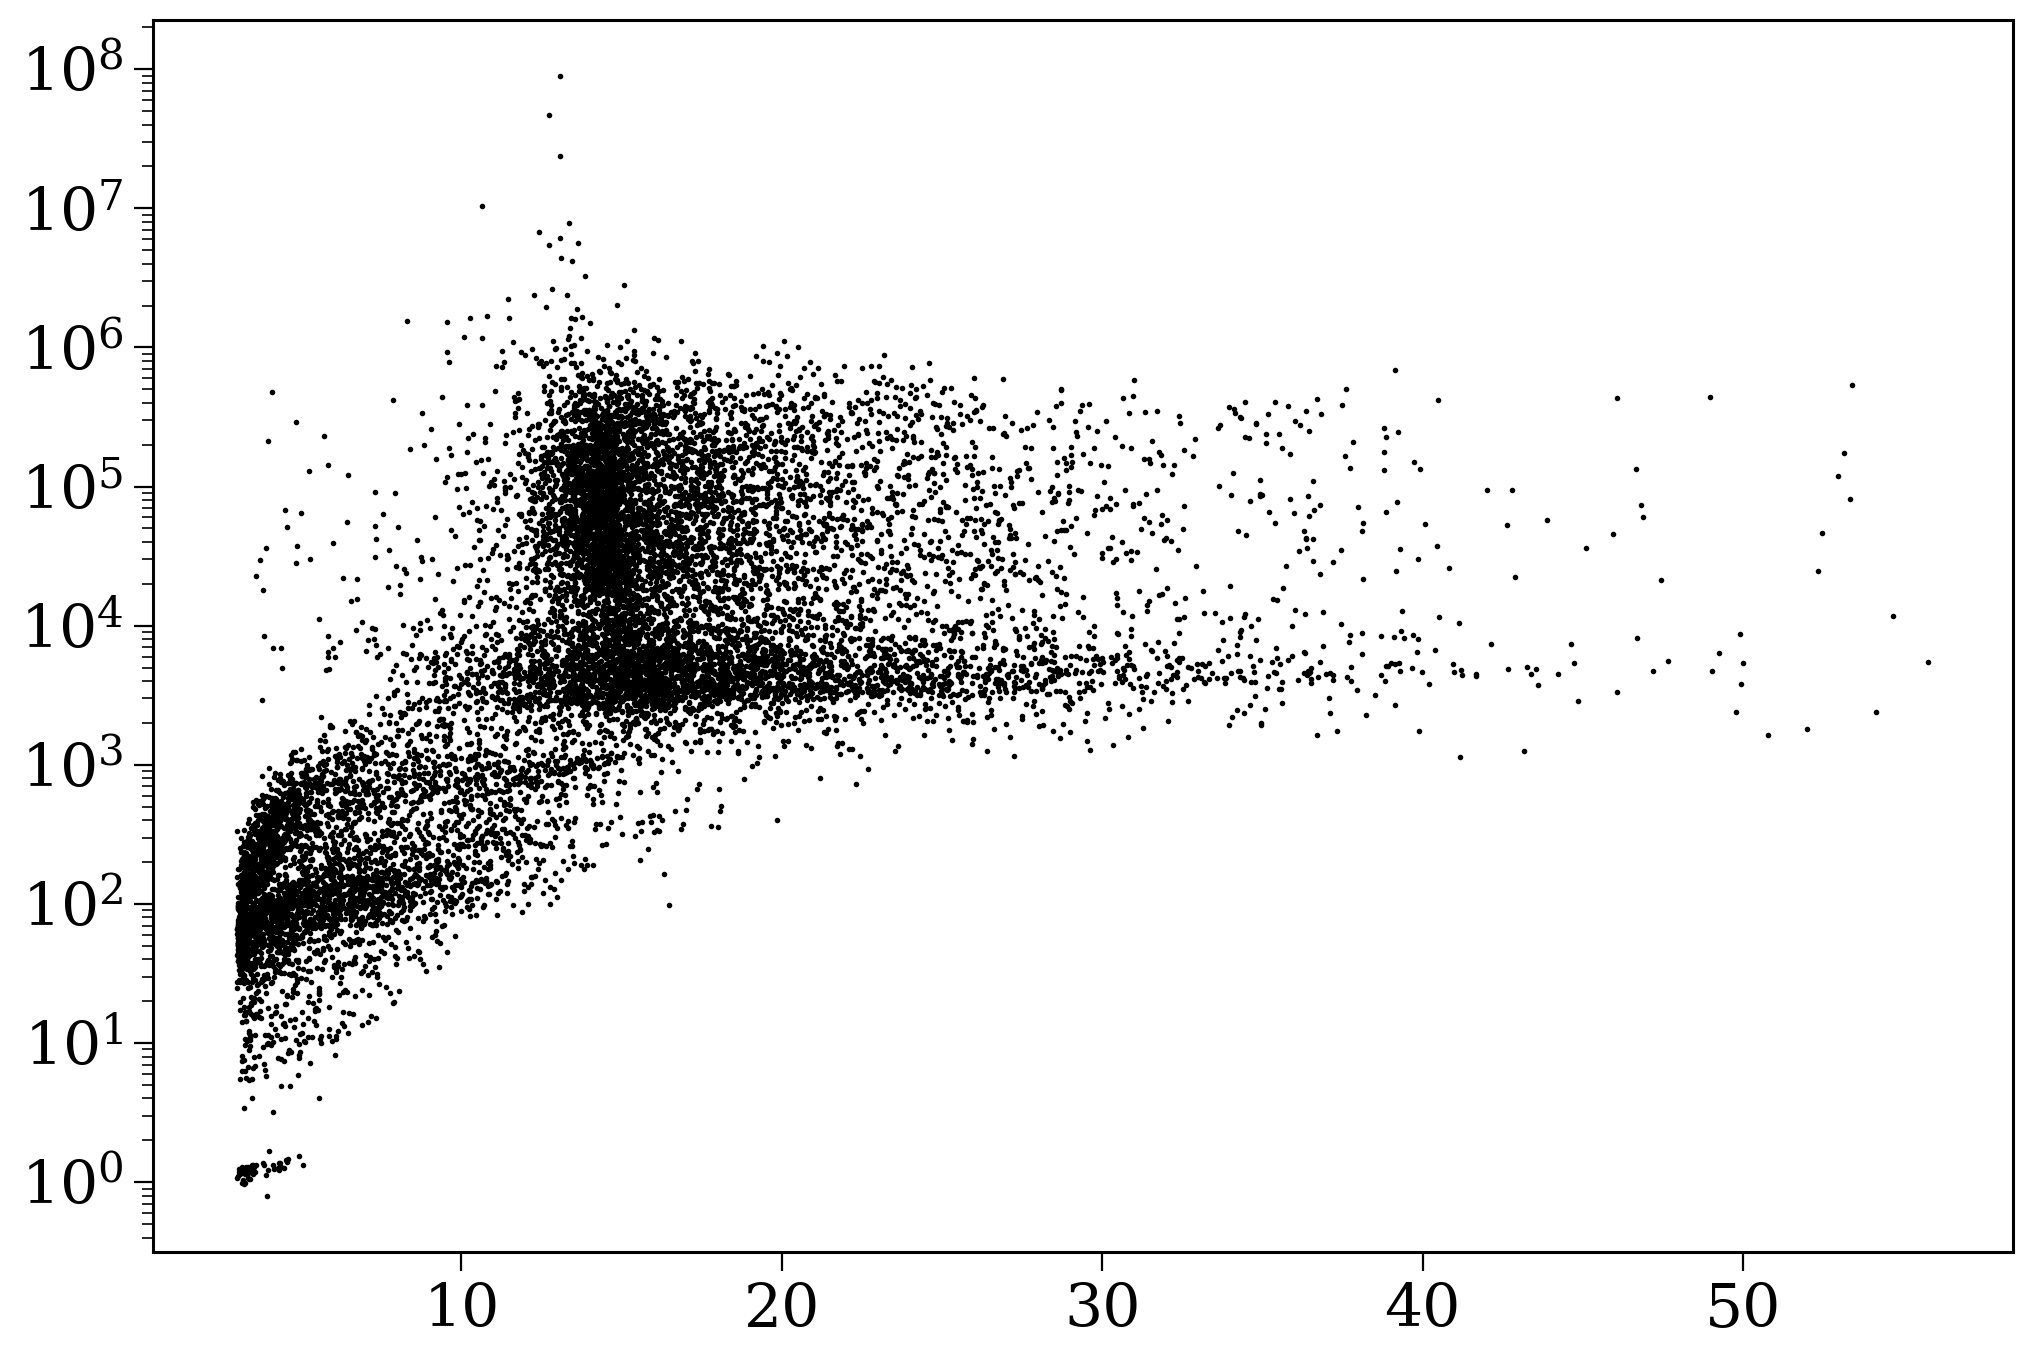

In [5]:
bound = data["Fiducial"]["sep"]["BH"] > 0
bh_wd = bound & (data["Fiducial"]["companion"]["BH"] >= 10) & (data["Fiducial"]["companion"]["BH"] <= 12)
plt.scatter(data["Fiducial"]["mass"]["BH"][bh_wd], data["Fiducial"]["sep"]["BH"][bh_wd], c='k', s=1)
plt.yscale("log")

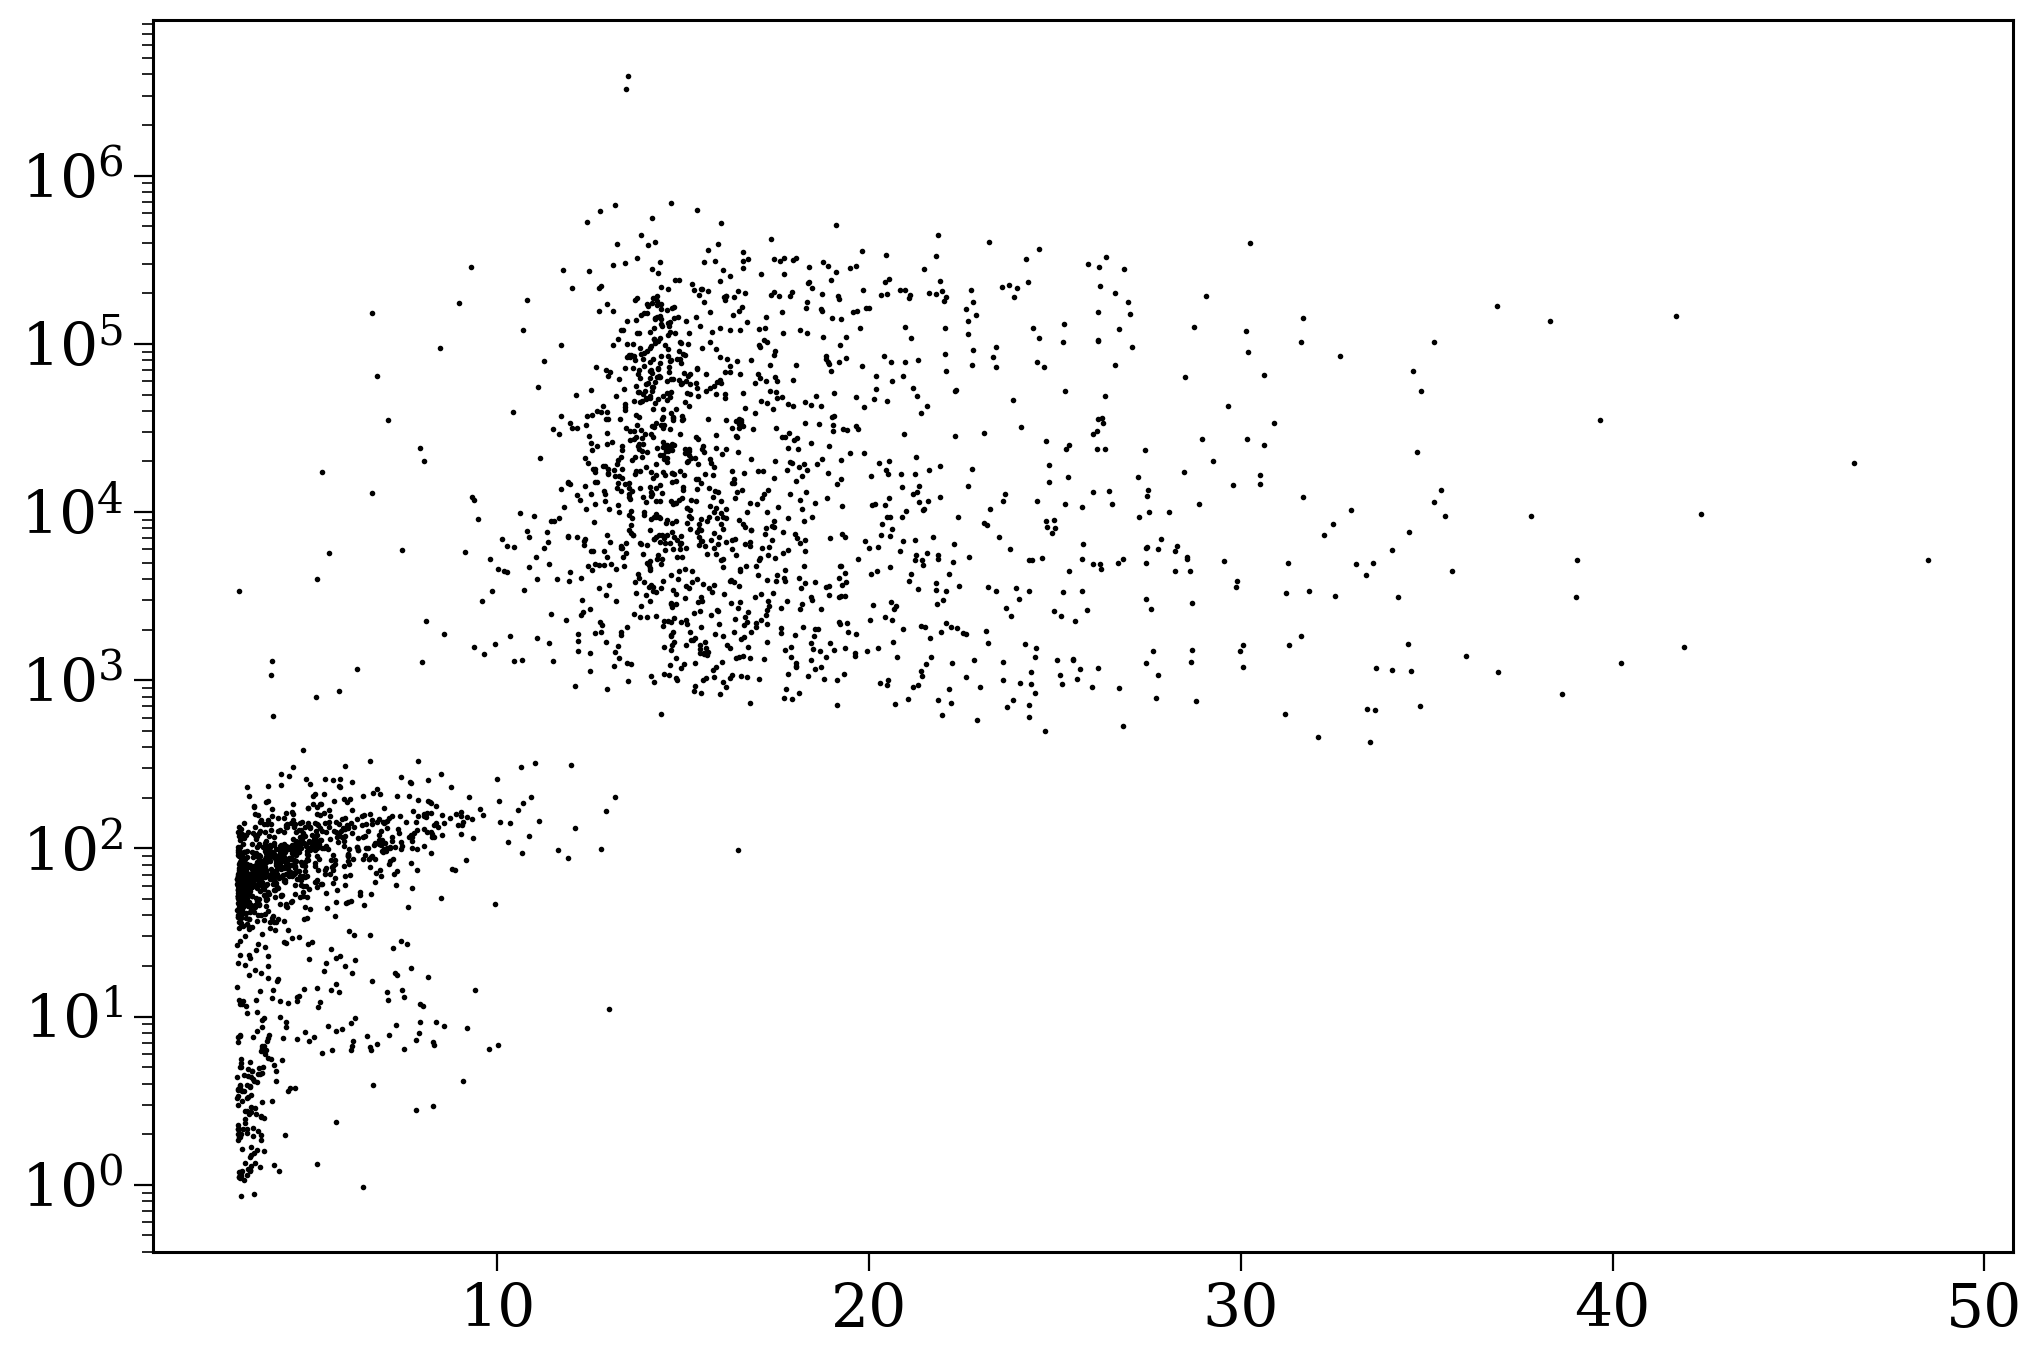

In [6]:
bound = data["Fiducial"]["sep"]["BH"] > 0
bh_star = bound & (data["Fiducial"]["companion"]["BH"] >= 0) & (data["Fiducial"]["companion"]["BH"] <= 10)
plt.scatter(data["Fiducial"]["mass"]["BH"][bh_star], data["Fiducial"]["sep"]["BH"][bh_star], c='k', s=1)
plt.yscale("log")

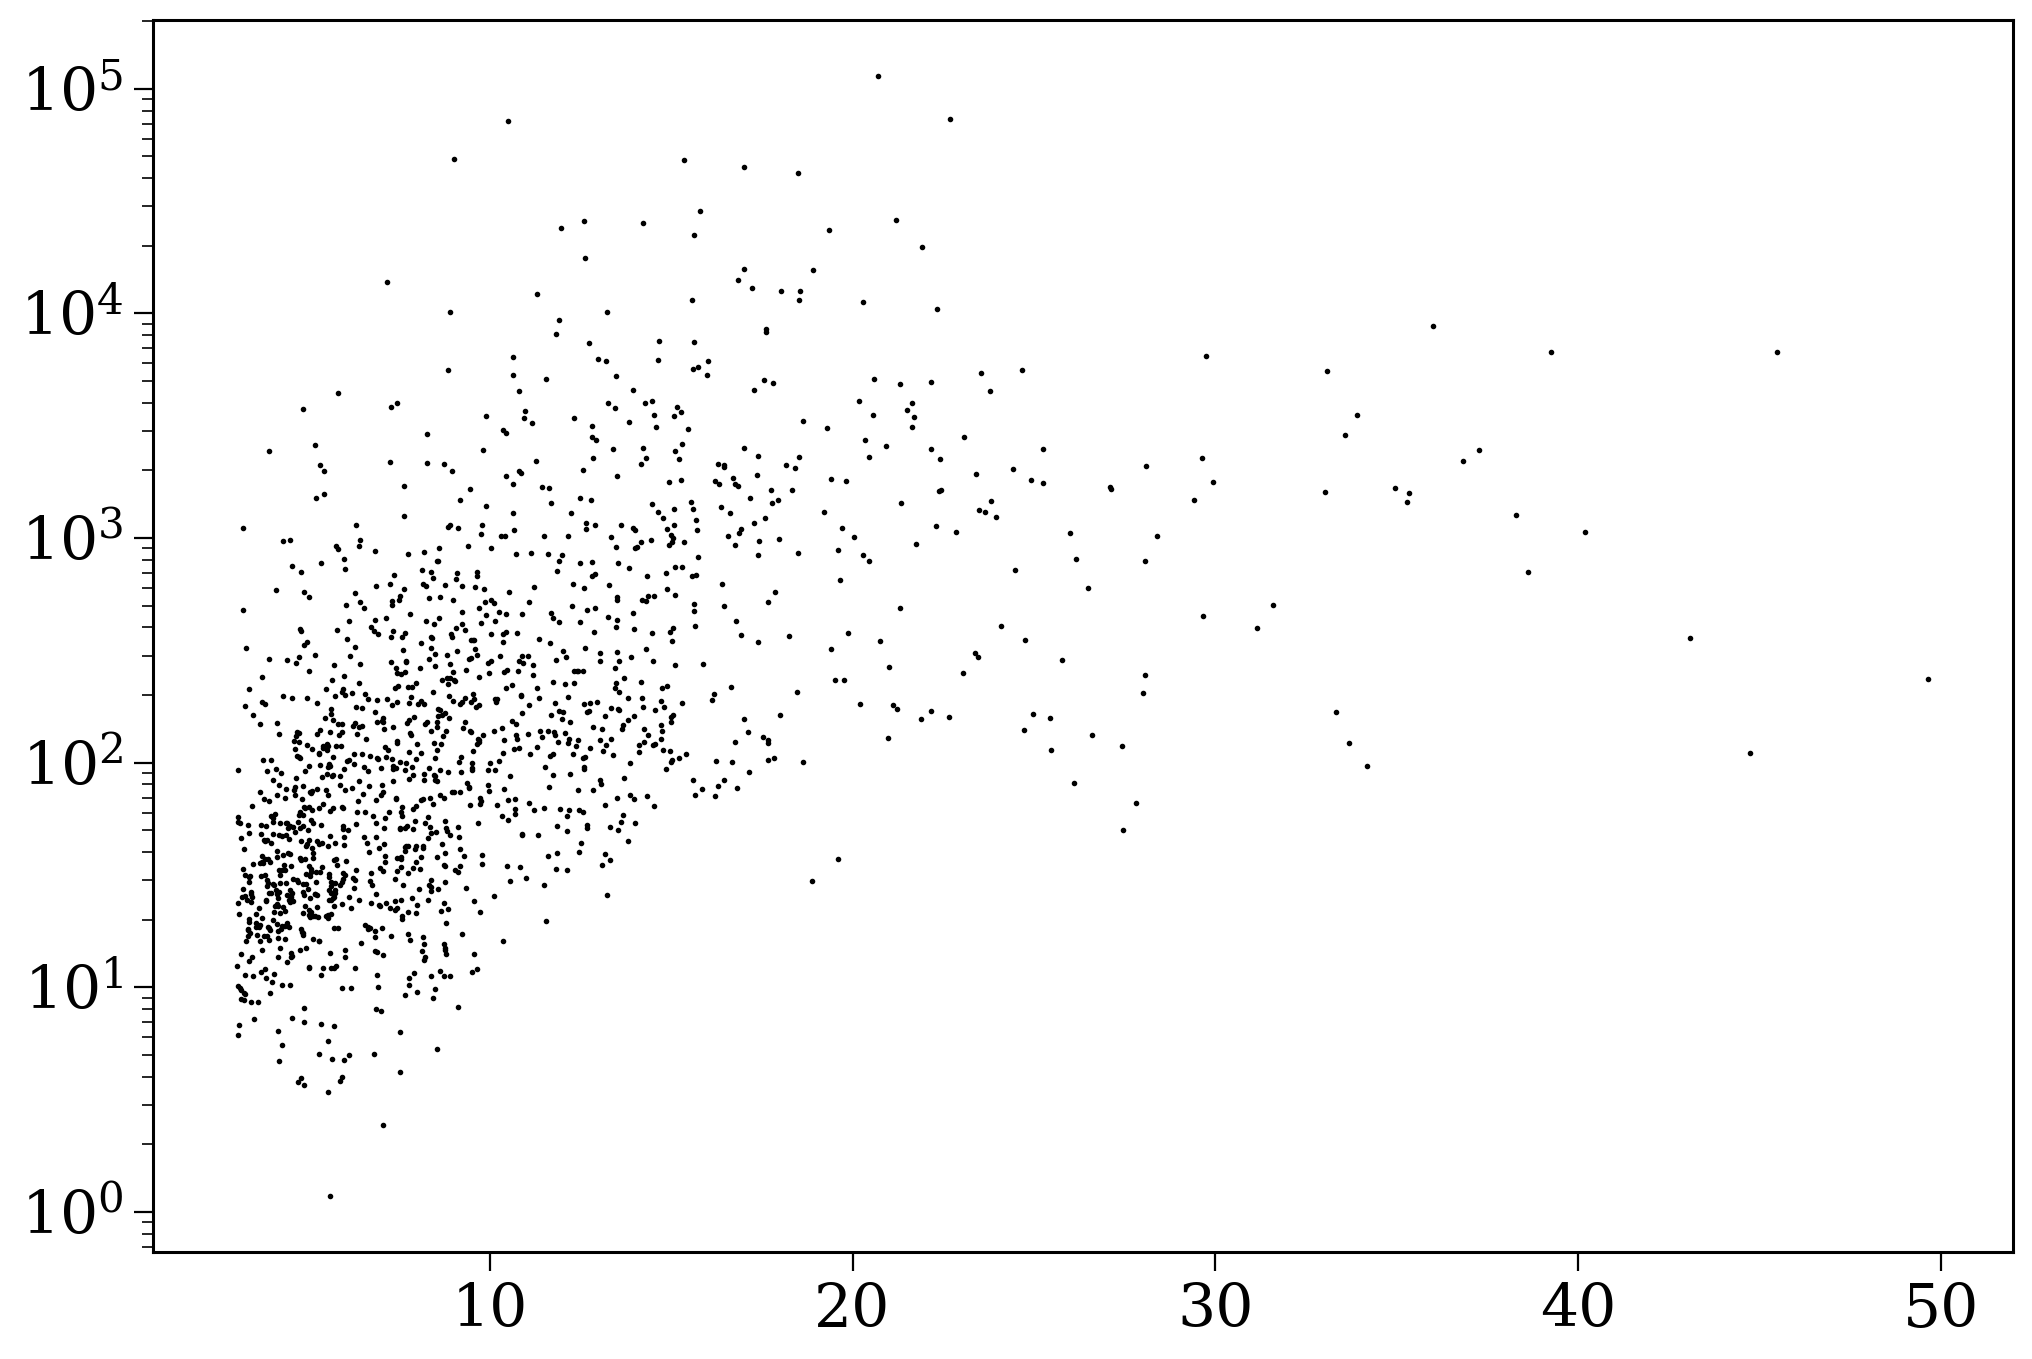

In [7]:
bound = data["Fiducial"]["sep"]["BH"] > 0
bh_ns = bound & (data["Fiducial"]["companion"]["BH"] == 13)
plt.scatter(data["Fiducial"]["mass"]["BH"][bh_ns], data["Fiducial"]["sep"]["BH"][bh_ns], c='k', s=1)
plt.yscale("log")

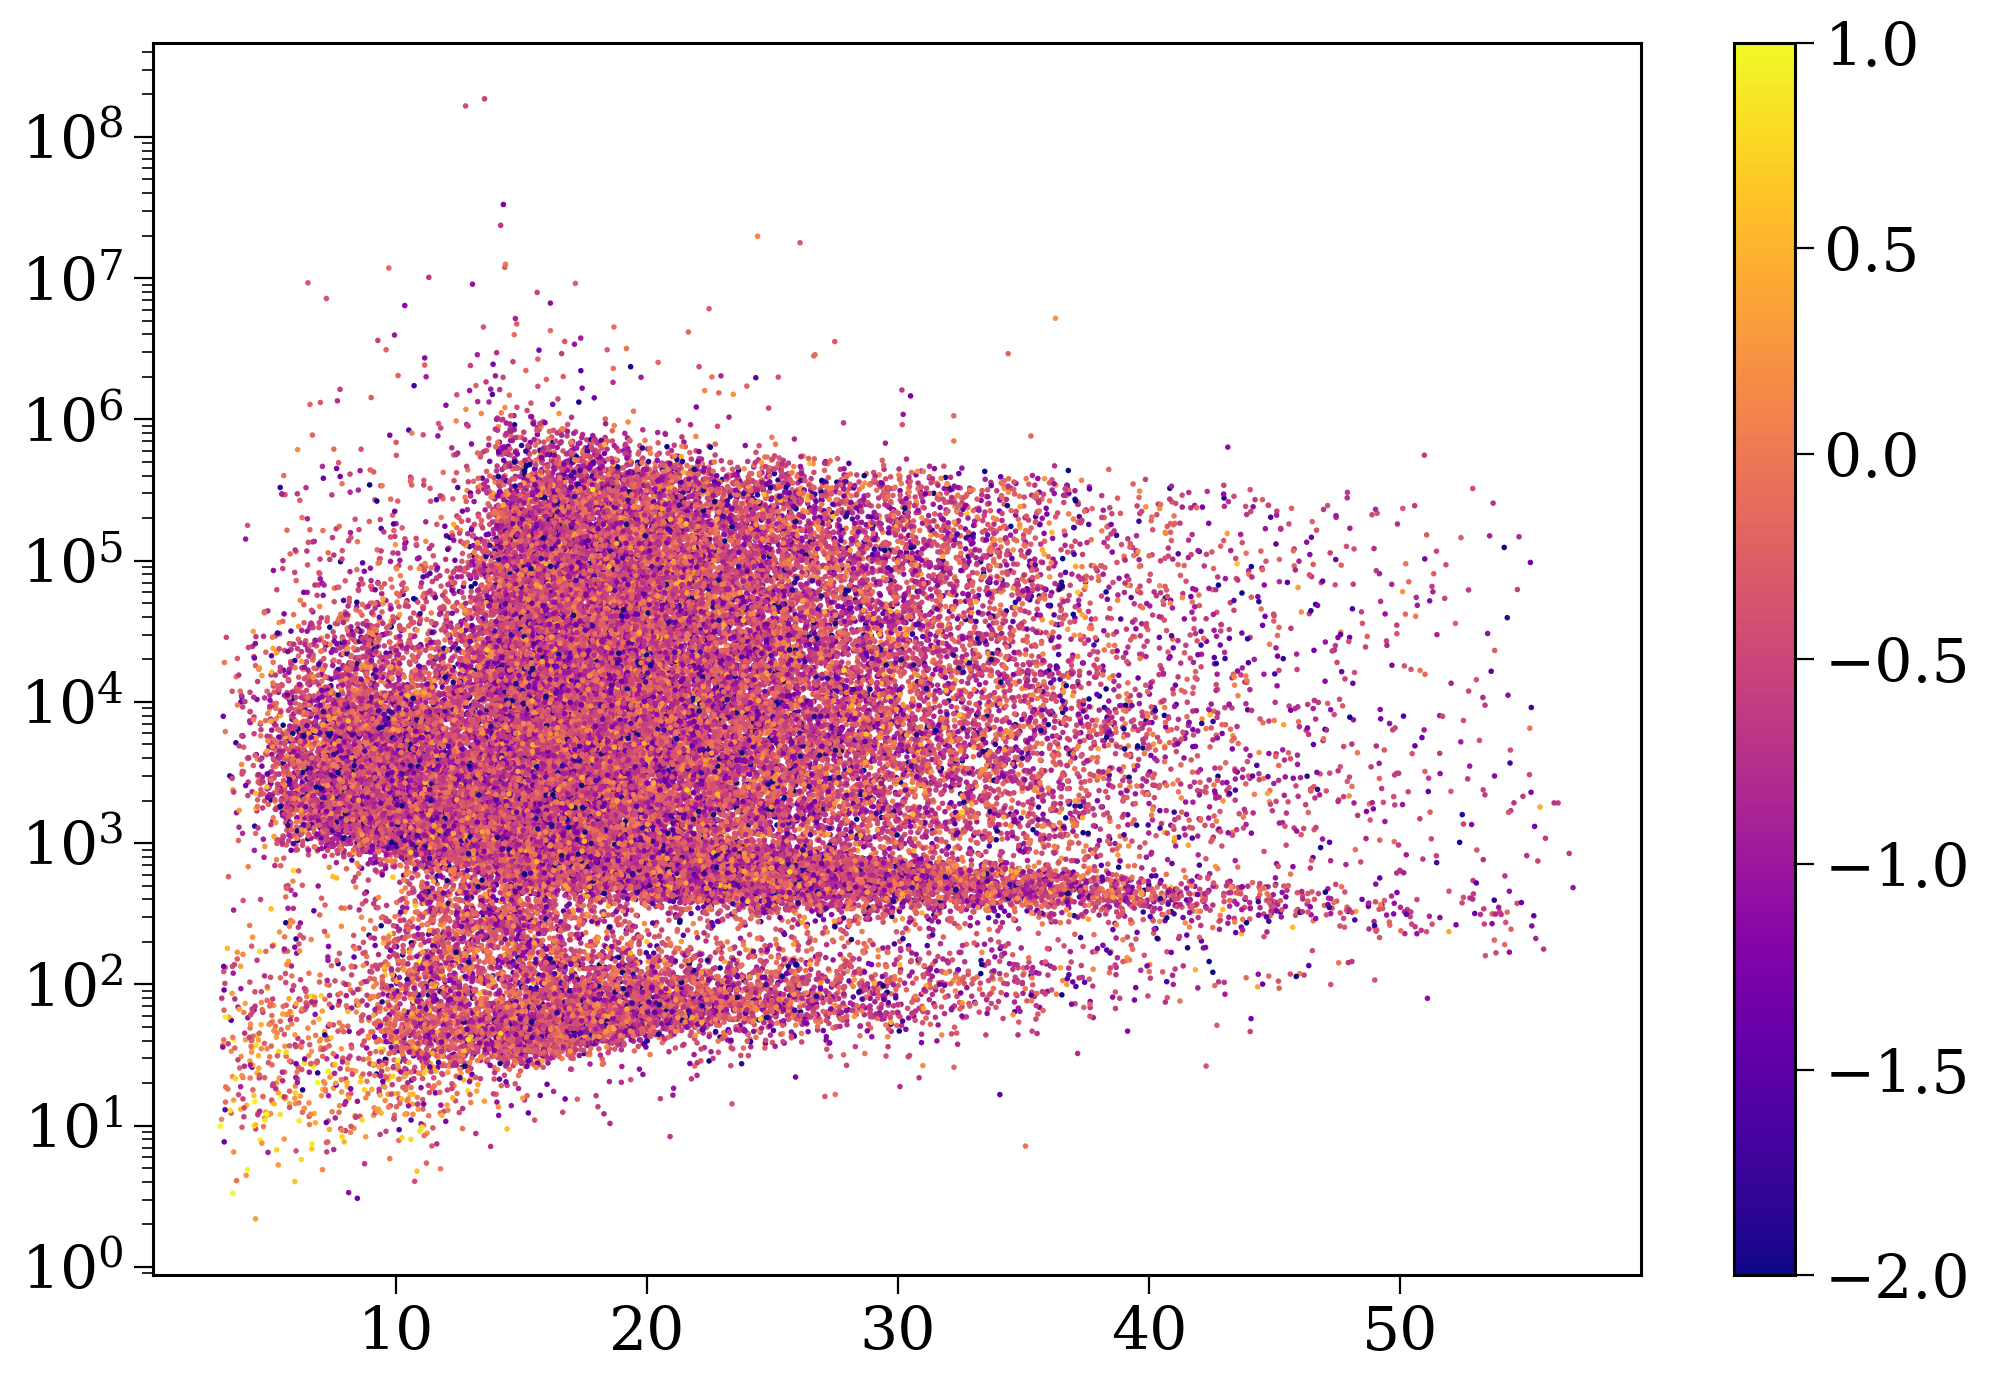

In [8]:
bound = data["Fiducial"]["sep"]["BH"] > 0
bh_bh = bound & (data["Fiducial"]["companion"]["BH"] == 14) & (data["Fiducial"]["primary"]["BH"])
scatter = plt.scatter(data["Fiducial"]["mass"]["BH"][bh_bh], data["Fiducial"]["sep"]["BH"][bh_bh], s=1, c=np.log10(np.abs(data["Fiducial"]["pos"]["BH"][bh_bh][:, 2])), vmin=-2, vmax=1, cmap="plasma")
plt.colorbar(scatter)
plt.yscale("log")

In [9]:
print(len(bh_star_pop))

5162


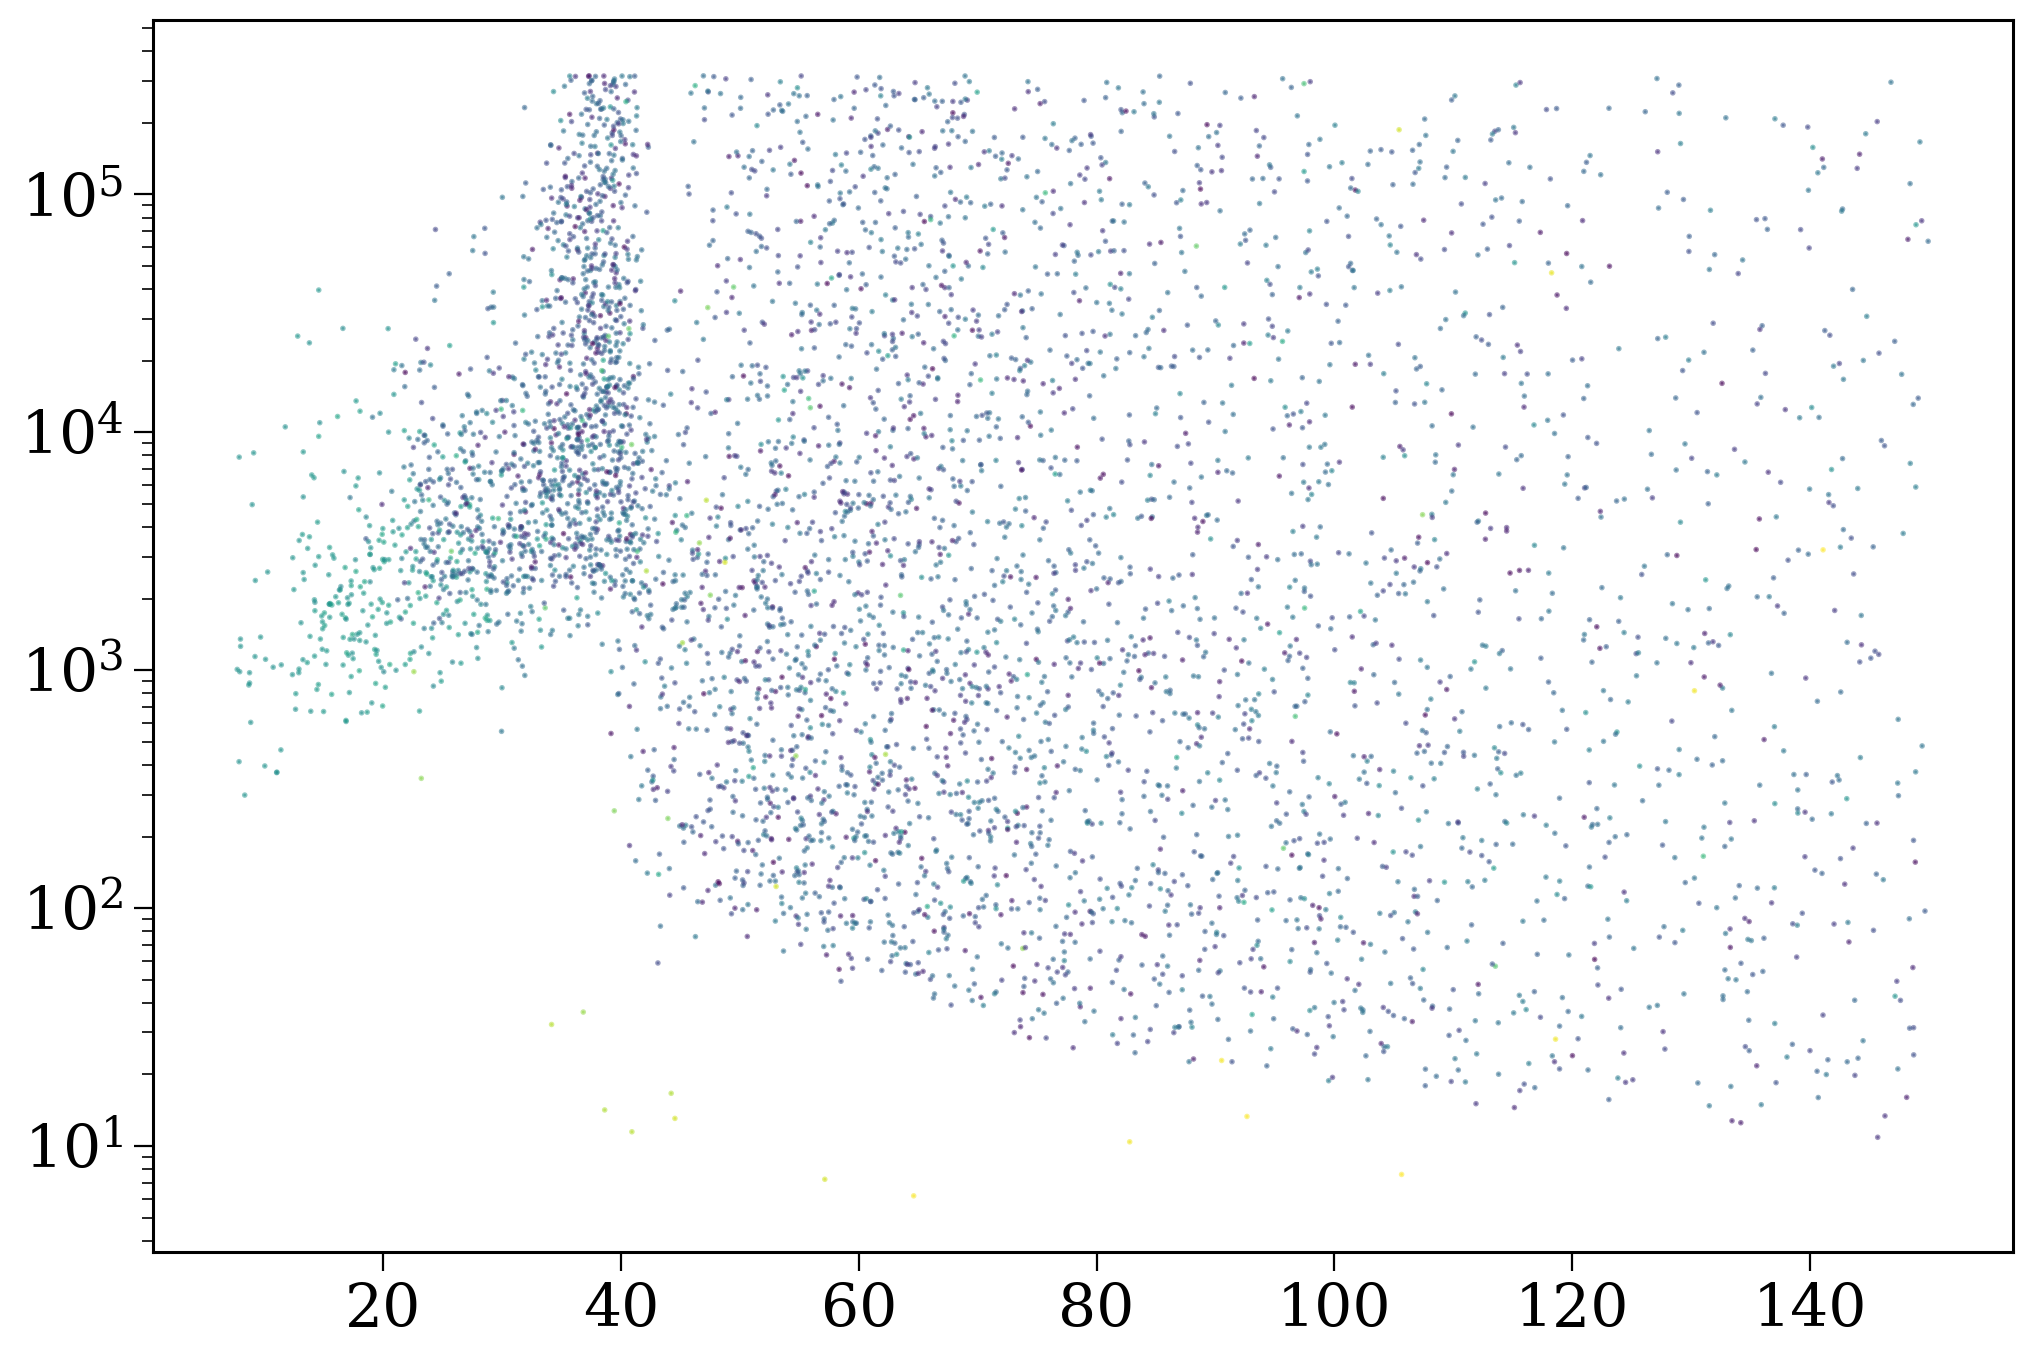

In [14]:
plt.scatter(bh_star_pop.initial_binaries["mass_1"], bh_star_pop.initial_binaries["porb"], s=1, c=np.log10(bh_star_pop.initial_binaries["mass_2"]), alpha=0.5)
plt.yscale("log")

Median mass: 6.6
Median mass: 17.0
Median mass: 15.0


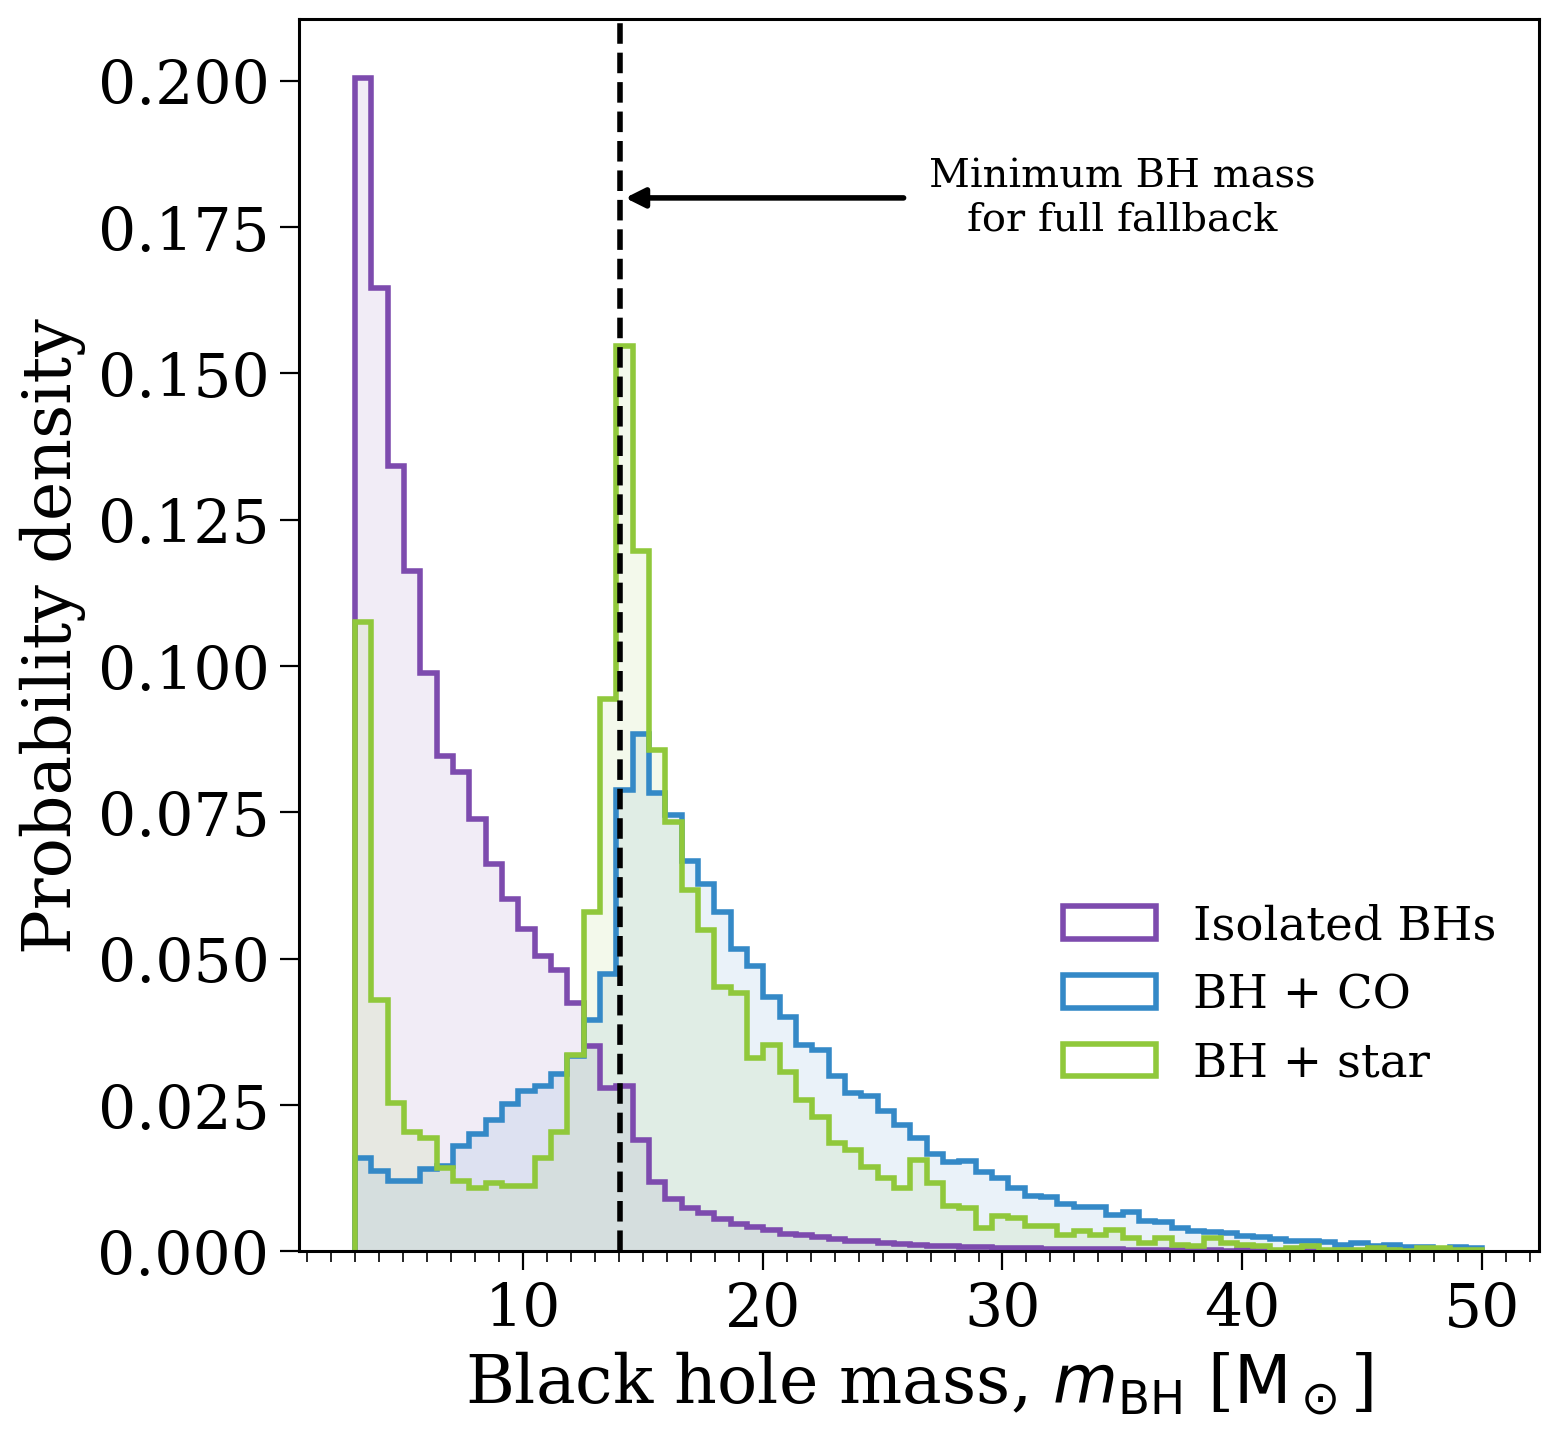

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))

bins = np.linspace(3, 50, 70)
density = True

for masses, colour, label in zip(
    [
        data["Fiducial"]["mass"]["BH"][data["Fiducial"]["sep"]["BH"] <= 0],
        data["Fiducial"]["mass"]["BH"][bh_bh | bh_ns | bh_wd],
        bh_star_pop.final_bpp["mass_1"],
    ],
    ["#7D4BAE", "#3489C7", "#90C83B"],
    ["Isolated BHs","BH + CO", "BH + star"],
):
    print(f"Median mass: {np.median(masses):1.1f}")
    plotting.nice_transparent_hist(
        ax, data=masses, bins=bins, colour=colour, alpha=0.1, label=label, density=density, lw=2
    )

    # ["Isolated BHs\n(Microlensing)","BH + star\n(Astrometry or XRBs)", "BH + compact object\n(Gravitational waves)"]

ax.axvline(14.04, ls='--', c='k', lw=2)

# ax.annotate("Minimum BH mass\nfor full fallback", xy=(12, 0.14), fontsize=0.6*fs, ha='center', va='center', rotation=90)
# ax.annotate("Minimum BH mass\nfor full fallback", xy=(14.04, 0.18), fontsize=0.5*fs, ha='center', va='center', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none"), rotation=90)
ax.annotate("Minimum BH mass\nfor full fallback", xy=(14.04, 0.18), xytext=(35, 0.18), fontsize=0.6*fs, ha='center', va='center',
            arrowprops=dict(arrowstyle="-|>", color='k', lw=2), bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="none"))

ax.xaxis.set_major_locator(plt.MultipleLocator(10))
ax.xaxis.set_minor_locator(plt.MultipleLocator(1))

leg = ax.legend(fontsize=0.7*fs, frameon=False, loc='lower right', bbox_to_anchor=(1, 0.1))#, labelspacing=1.2)

ax.set(
    xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
    ylabel=r"Probability density",
)

# plt.savefig("../plots/bh_binary_masses.pdf", bbox_inches='tight', format='pdf')
plt.show()

[Text(0.5, 0, '$x$ [kpc]'),
 Text(0, 0.5, '$z$ [kpc]'),
 (-35.0, 35.0),
 (-15.0, 15.0),
 None]

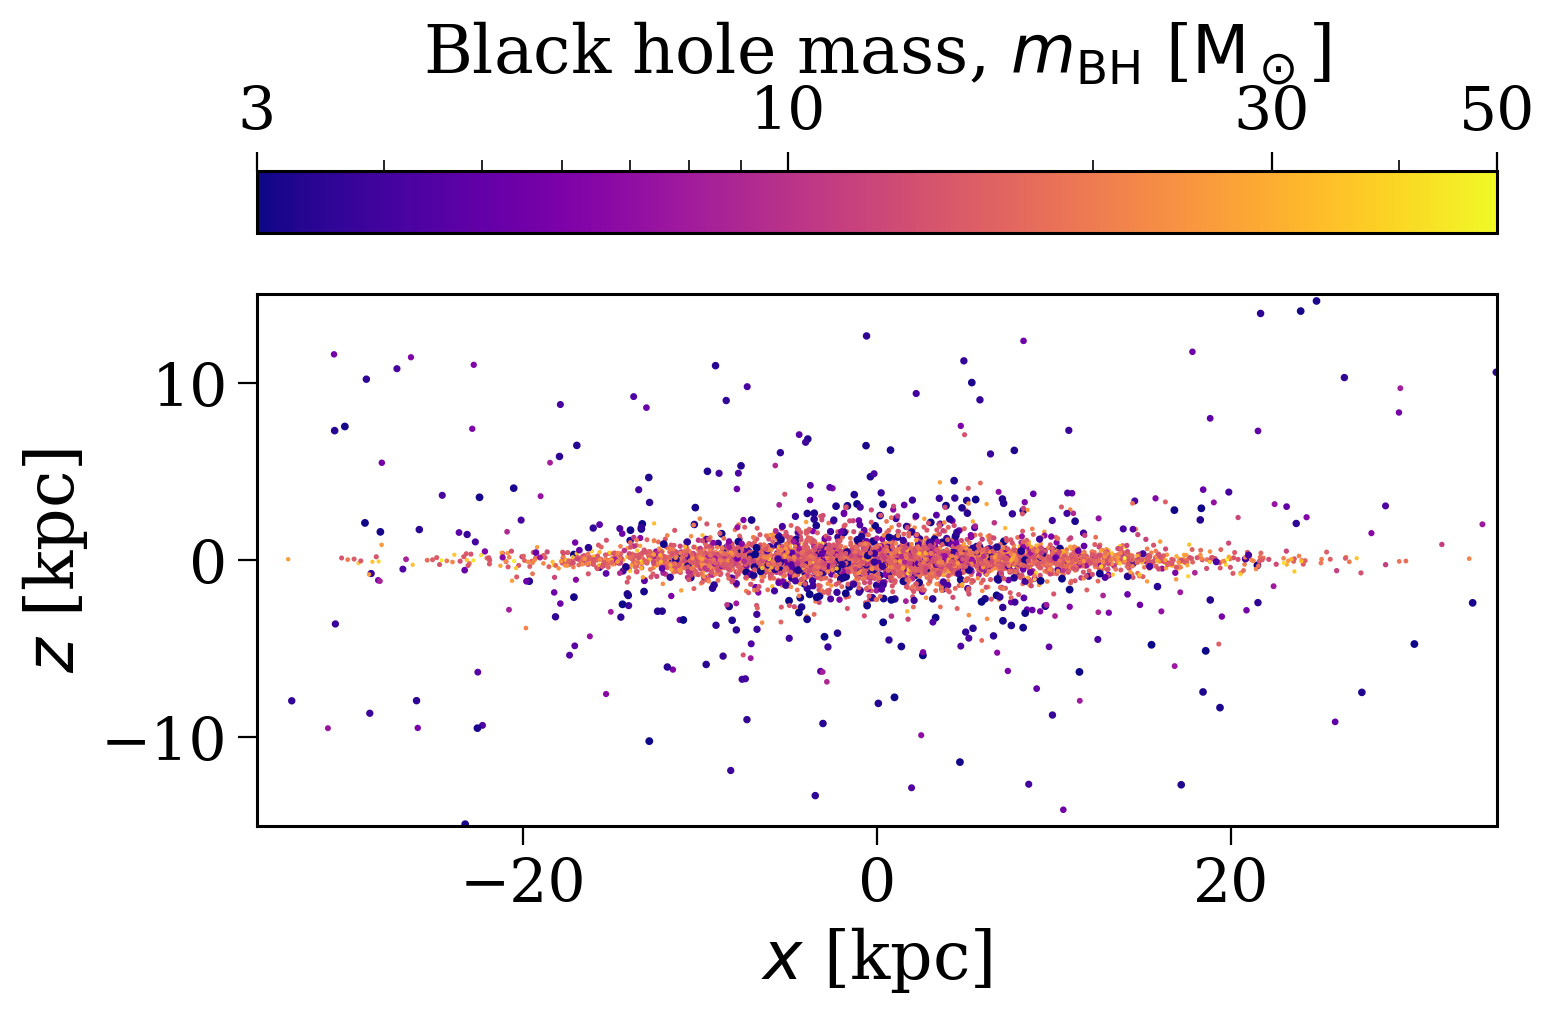

In [17]:
fig, ax = plt.subplots(figsize=(8, 8))

# ax.scatter(data["Fiducial"]["pos"]["BH"][:, 0][bh_bh], data["Fiducial"]["pos"]["BH"][:, 2][bh_bh], s=1)
# ax.scatter(data["Fiducial"]["pos"]["BH"][:, 0][bh_ns], data["Fiducial"]["pos"]["BH"][:, 2][bh_ns], s=1)
scatter = ax.scatter(bh_star_pop.final_pos[:, 0], bh_star_pop.final_pos[:, 2], s=10 / bh_star_pop.final_bpp["mass_1"], c=bh_star_pop.final_bpp["mass_1"], cmap="plasma", norm=mpl.colors.LogNorm(vmin=3, vmax=50))
cbar = fig.colorbar(scatter, label=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]", format="%.0f", orientation="horizontal", location='top')
cbar.set_ticks([3, 10, 30, 50], labels=[3, 10, 30, 50])

ax.set(
    xlabel=r"$x$ [kpc]",
    ylabel="$z$ [kpc]",
    xlim=(-35, 35),
    ylim=(-15, 15),
    aspect='equal'
)

Text(0, 0.5, 'Distance from Galactic plane, $|z|$ [kpc]')

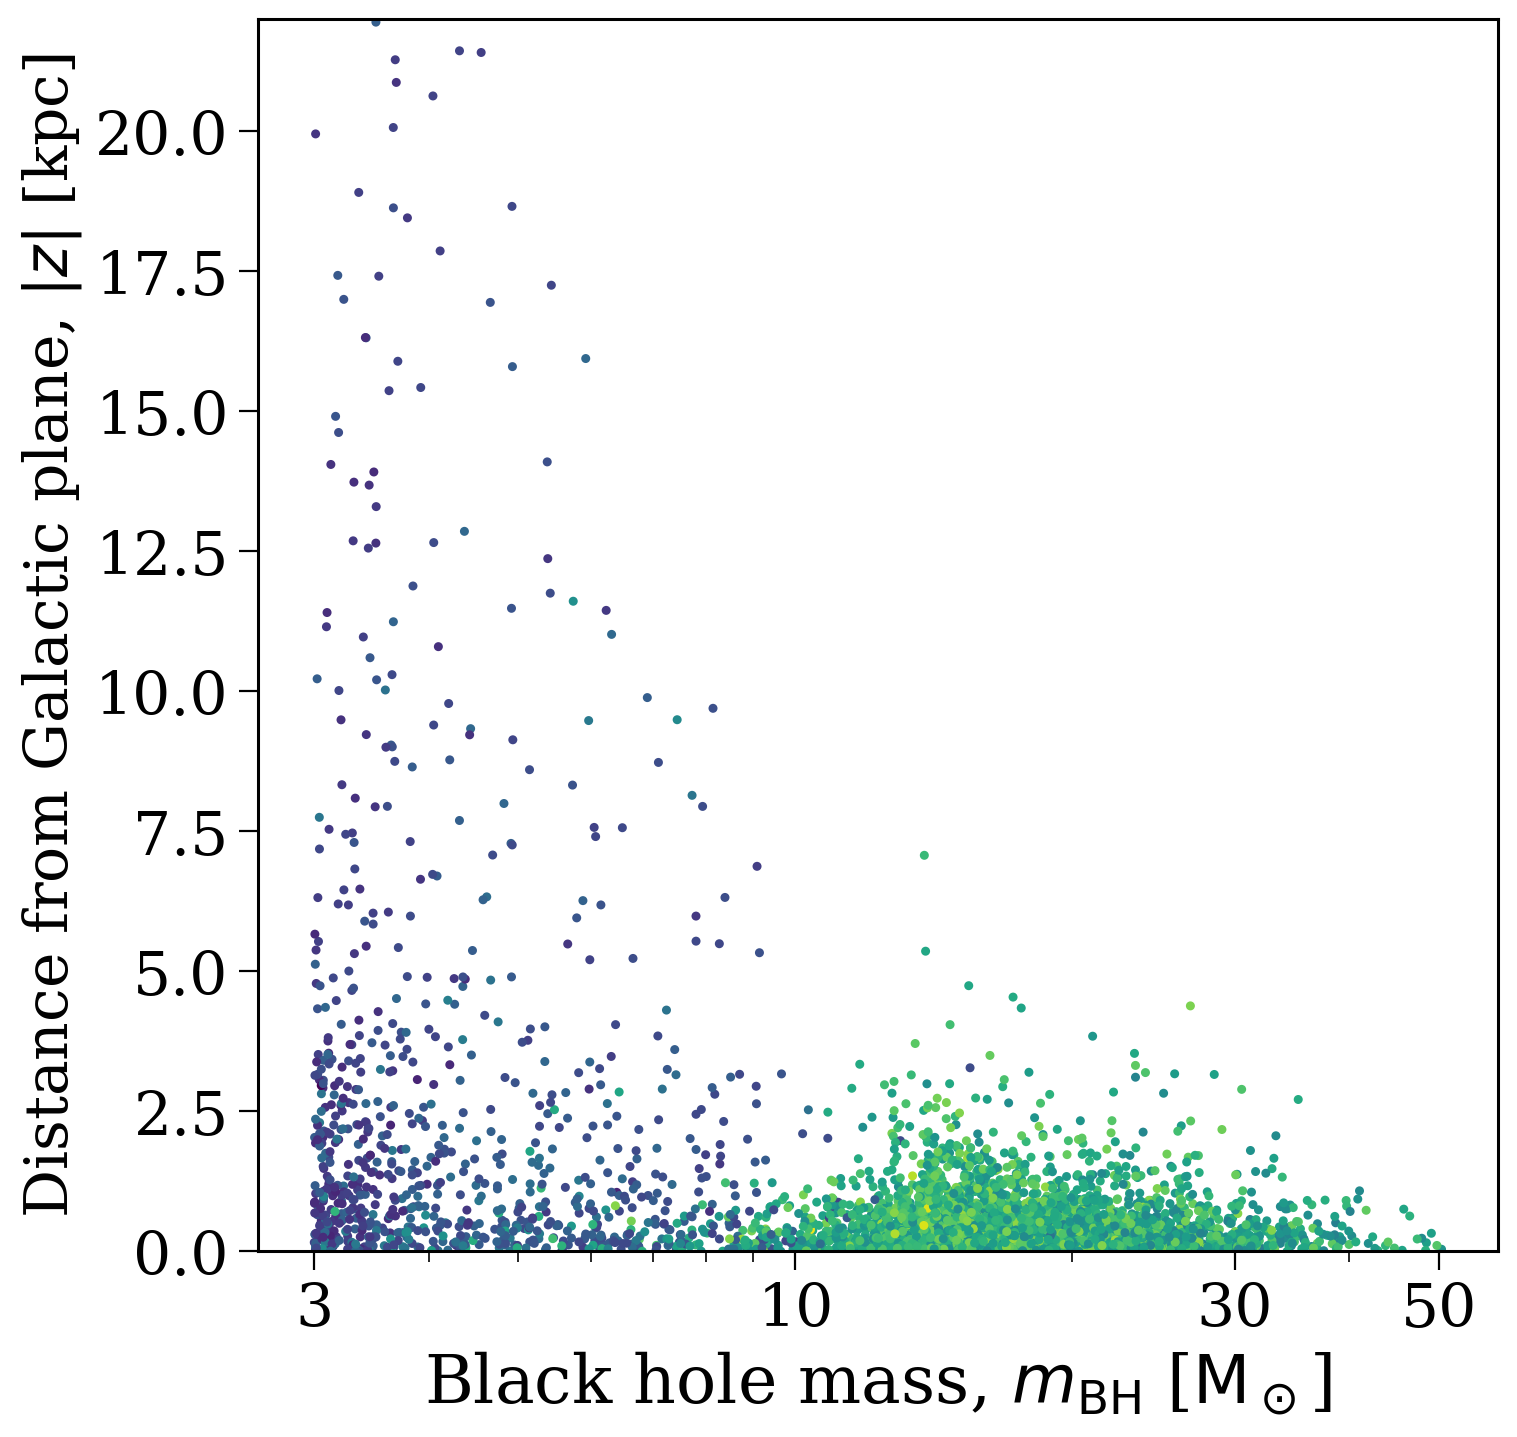

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    bh_star_pop.final_bpp["mass_1"], abs(bh_star_pop.final_pos[:, 2]), s=5, c=np.log10(bh_star_pop.final_bpp["porb"])
)
ax.set(
    xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
    ylabel=r"Distance from Galactic plane, $|z|$ [kpc]",
    xscale="log",
    # yscale="log",
    ylim=(0, 22),
    xticks=[3, 10, 30, 50],
    xticklabels=[3, 10, 30, 50]
)
ax.set_ylabel(ax.get_ylabel(), fontsize=0.9*fs)

In [14]:
((bh_star_pop.final_bpp["mass_2"] > 8) & (bh_star_pop.final_bpp["porb"] < 1e4)).sum() 

np.int64(22)

<Axes: >

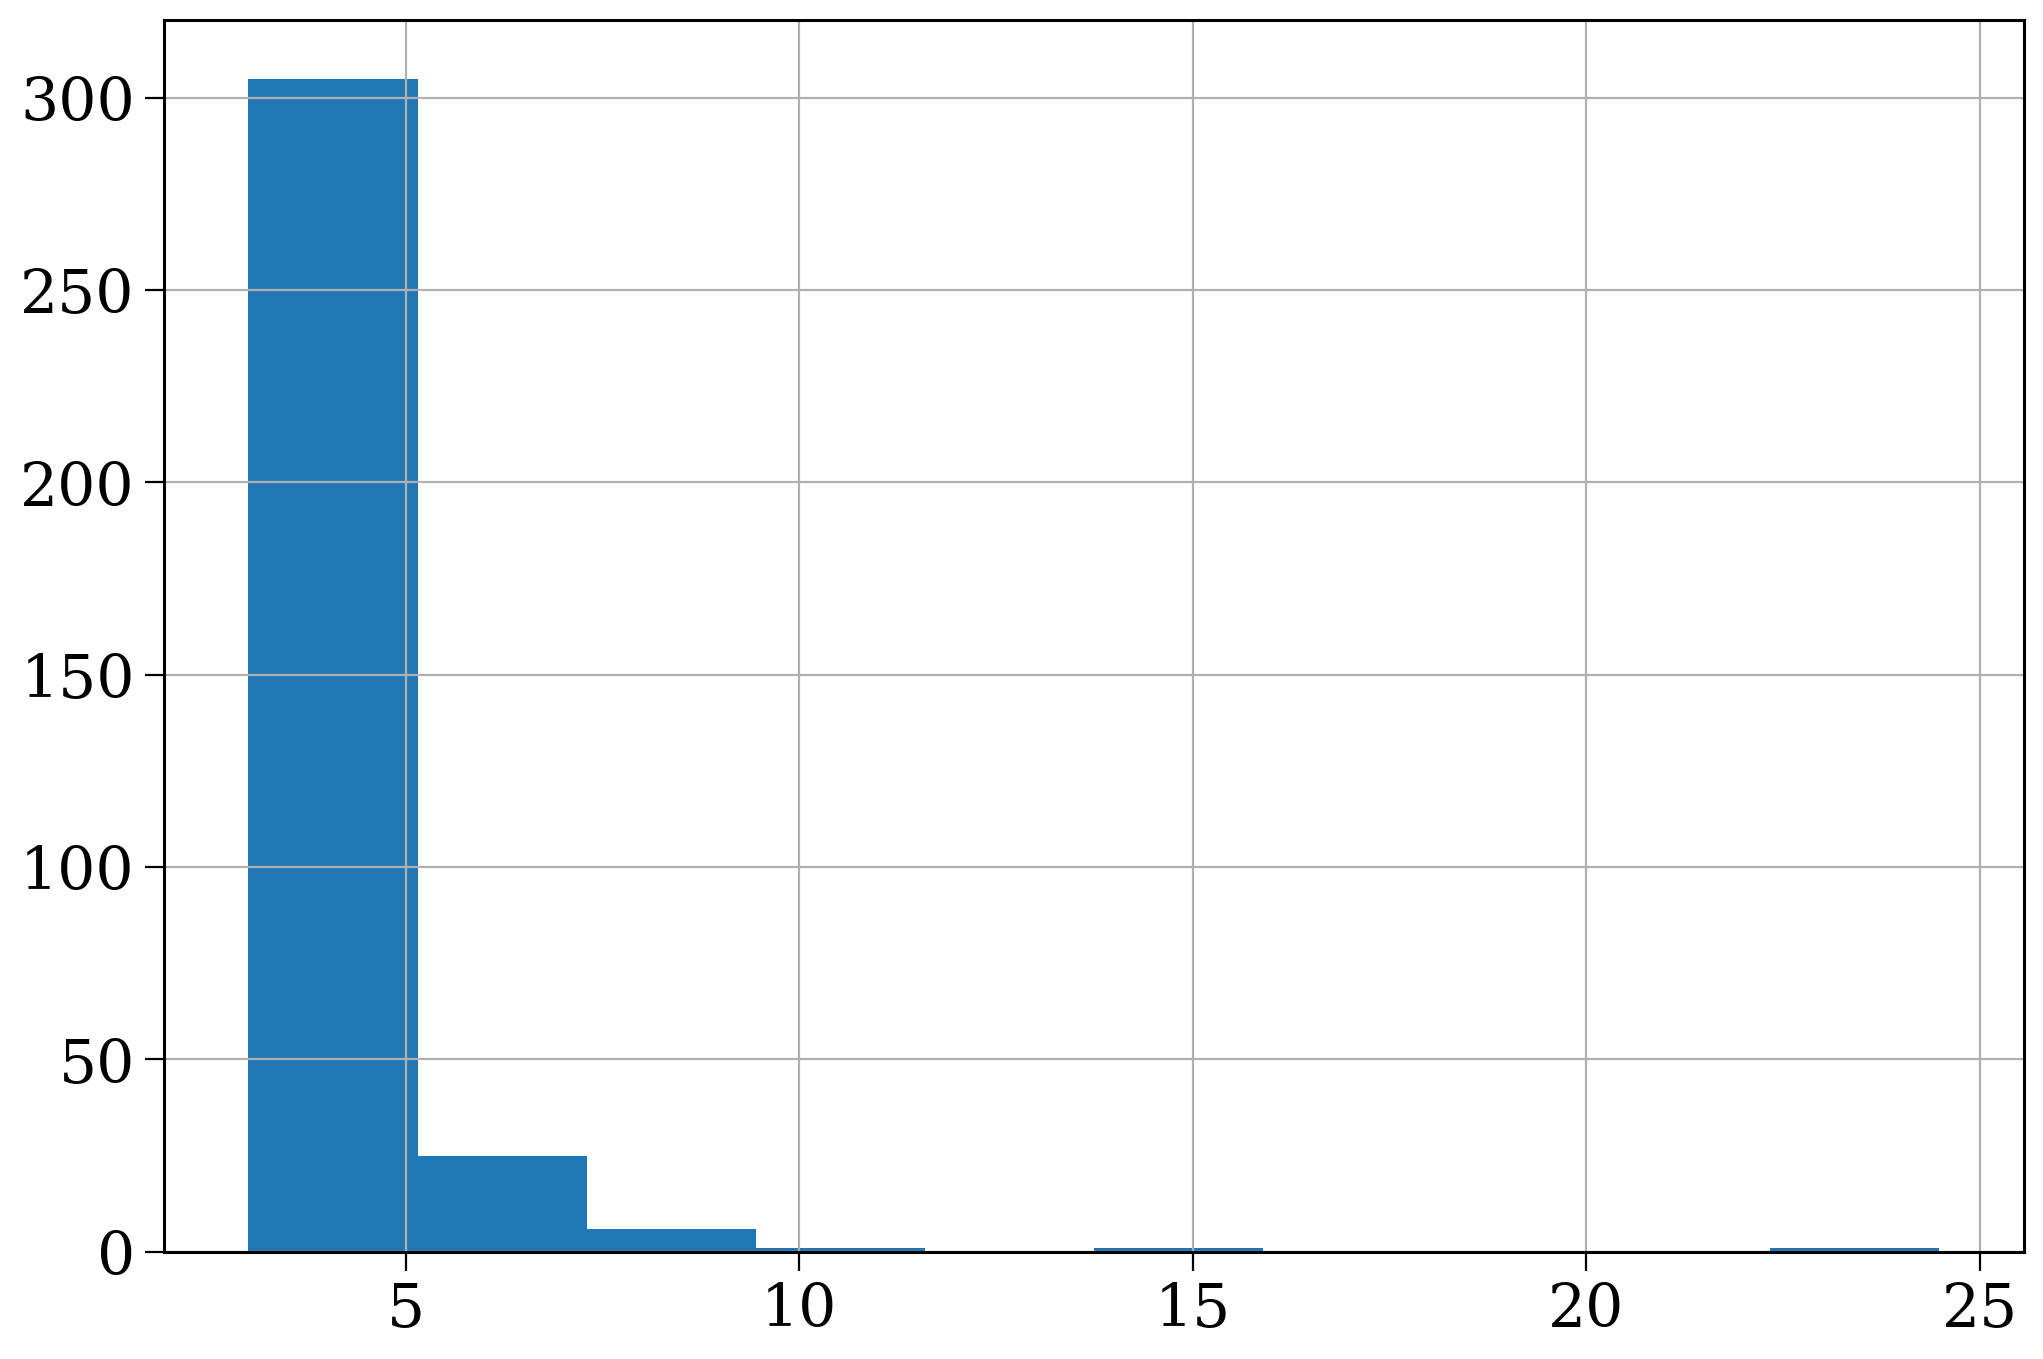

In [19]:
bh_star_pop.final_bpp["mass_1"][(bh_star_pop.final_bpp["RRLO_2"] > 1)].hist()

In [16]:
# convert an orbital period to separation using Kepler's third law, assuming a total mass of 20 Msun
def porb_to_sep(porb, m1=20, m2=0):
    import astropy.constants as consts
    import astropy.units as u
    sep_kpc = (consts.G * (m1 + m2) * u.Msun * (porb * u.day)**2 / (4 * np.pi**2))**(1/3)
    return sep_kpc.to(u.AU)

porb_to_sep(1e5)

<Quantity 114.4487483 AU>

In [19]:
test = cogsworth.pop.Population(10, use_default_BSE_settings=True)
test.create_population()

Run for 10 binaries
Sampled 12 binaries
[7e-03s] Sample initial binaries
[0.7s] Evolve binaries (run COSMIC)


Integrating orbits: 100%|██████████| 12/12 [00:00<00:00, 1440.52it/s]

[0.2s] Integrate galactic orbits (run gala)
Overall: 0.9s


In [22]:
test.orbits[0].t

<Quantity [ 1064.22163258,  1065.22163258,  1066.22163258, ...,
           11997.22163258, 11998.22163258, 11999.22163258] Myr>

In [534]:
bh_star_pop.kick_info[(bh_star_pop.kick_info["vsys_1_total"] > 0) & (bh_star_pop.kick_info["natal_kick"] == 0)]["vsys_1_total"].describe()

count    3181.000000
mean        0.018457
std         0.031743
min         0.000164
25%         0.004394
50%         0.010271
75%         0.023339
max         0.829603
Name: vsys_1_total, dtype: float64

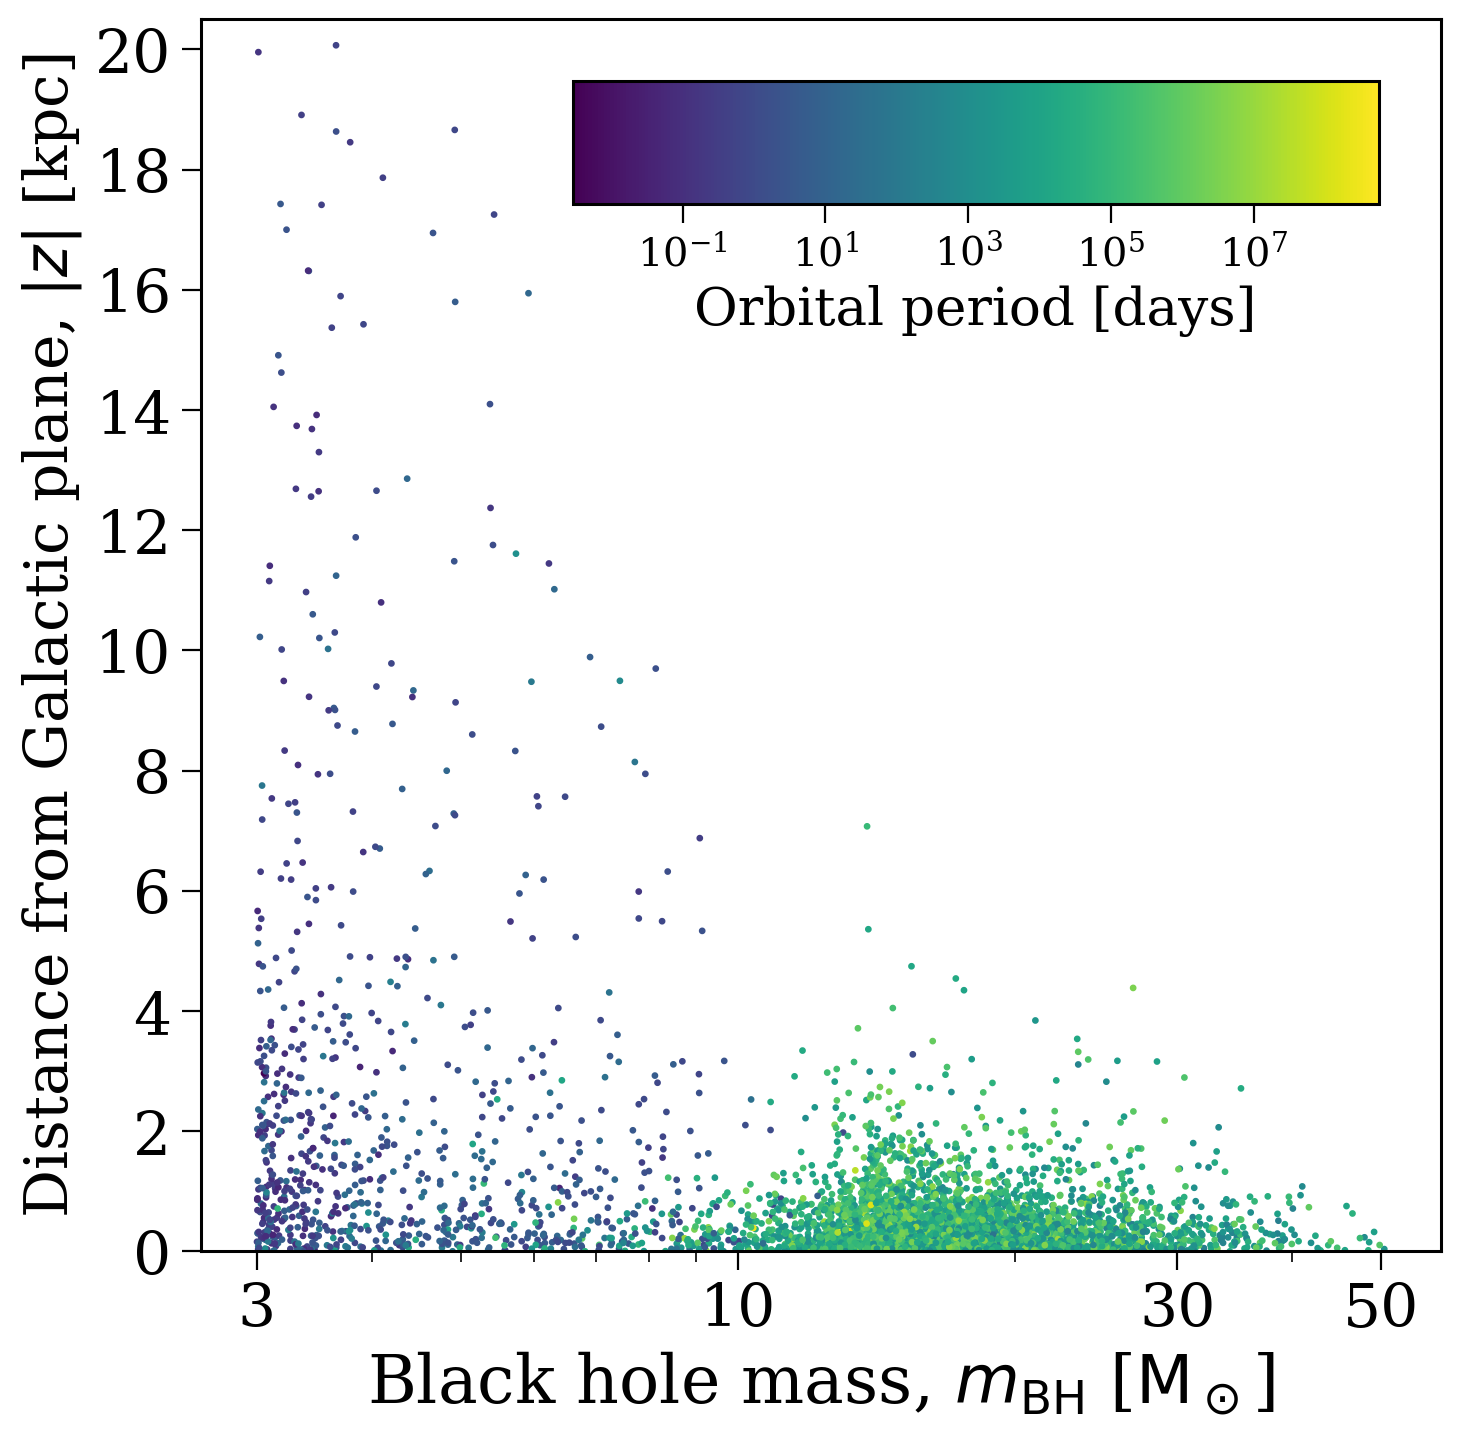

In [20]:
fig, ax = plt.subplots(figsize=(8, 8))

scatter = ax.scatter(
    bh_star_pop.final_bpp["mass_1"], abs(bh_star_pop.final_pos[:, 2]), s=2, c=bh_star_pop.final_bpp["porb"],
    norm=mpl.colors.LogNorm(), rasterized=True
)

inset_ax = ax.inset_axes([0.3, 0.85, 0.65, 0.1])
cb = plt.colorbar(scatter, cax=inset_ax, label="Orbital period [days]", orientation="horizontal")
cb.set_label(cb.ax.get_xlabel(), fontsize=0.8*fs)
cb.ax.tick_params(labelsize=0.6*fs)

ax.set(
    xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
    ylabel=r"Distance from Galactic plane, $|z|$ [kpc]",
    xscale="log",
    # yscale="log",
    ylim=(0, 20.5),
    xticks=[3, 10, 30, 50],
    xticklabels=[3, 10, 30, 50]
)
ax.set_ylabel(ax.get_ylabel(), fontsize=0.9*fs)
ax.yaxis.set_major_locator(plt.MultipleLocator(2))

# plt.savefig("../plots/bh_binary_mbh_vs_z.pdf", bbox_inches='tight', format='pdf')

plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


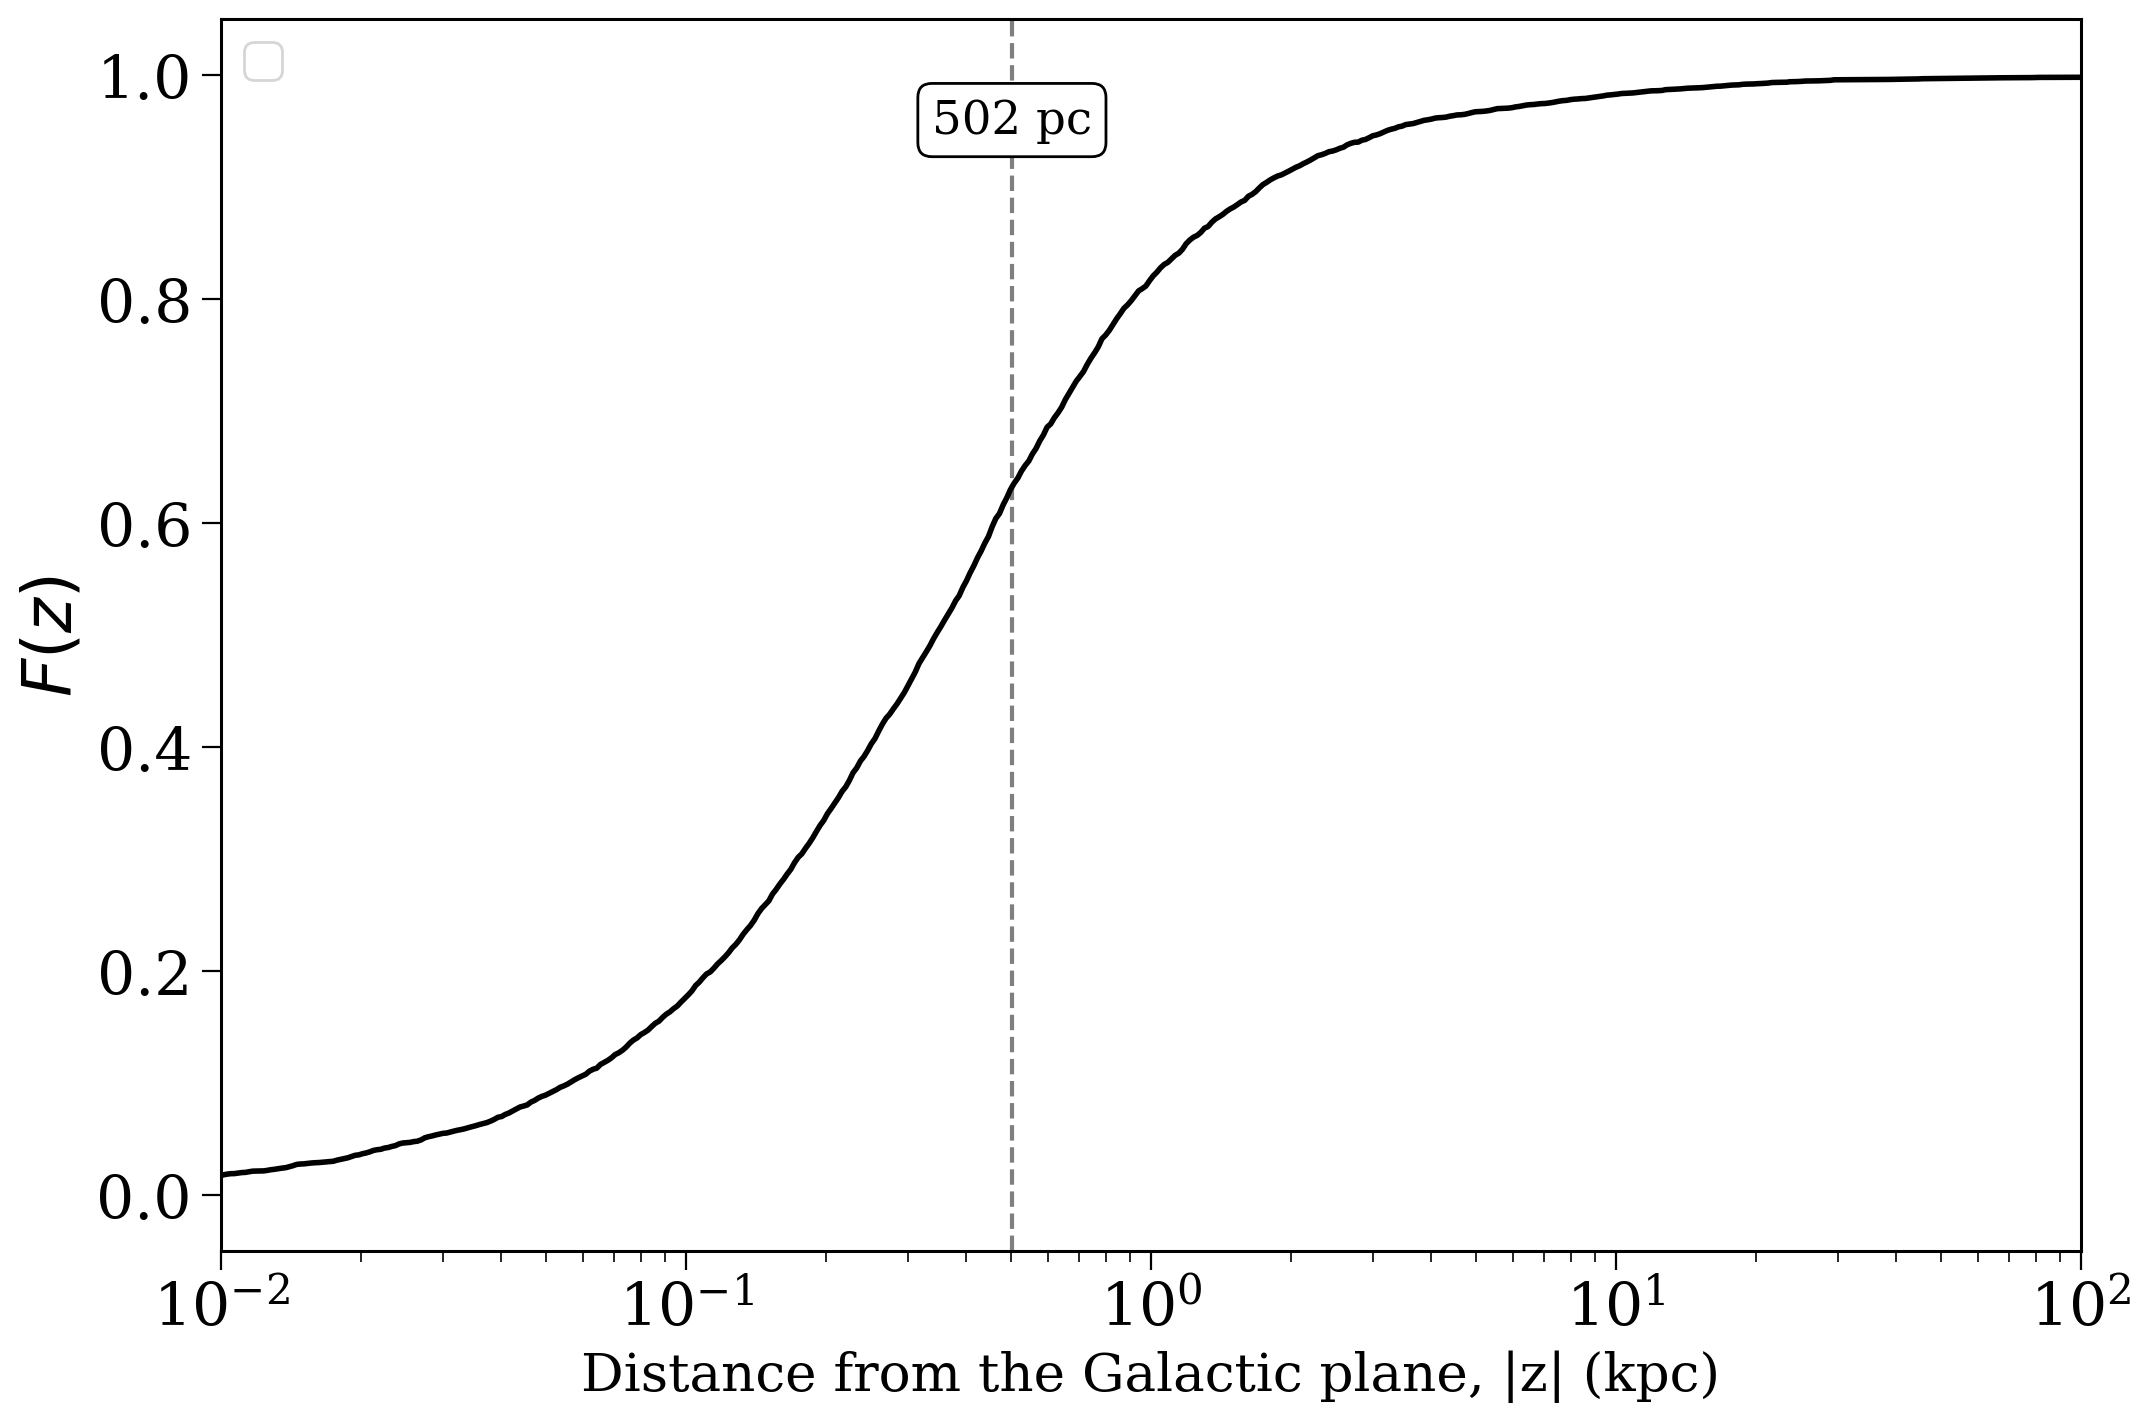

(np.float64(0.5021049753309124),
 None,
 <Figure size 1200x800 with 1 Axes>,
 <Axes: xlabel='Distance from the Galactic plane, |z| (kpc)', ylabel='$F(z)$'>)

In [21]:
plotting.estimate_scale_height_cdf(
    bh_star_pop.final_pos[:, 2].value,
    xlim=(1e-2, 1e2),
    plot=True,
    scale_height_loc=0.98
)

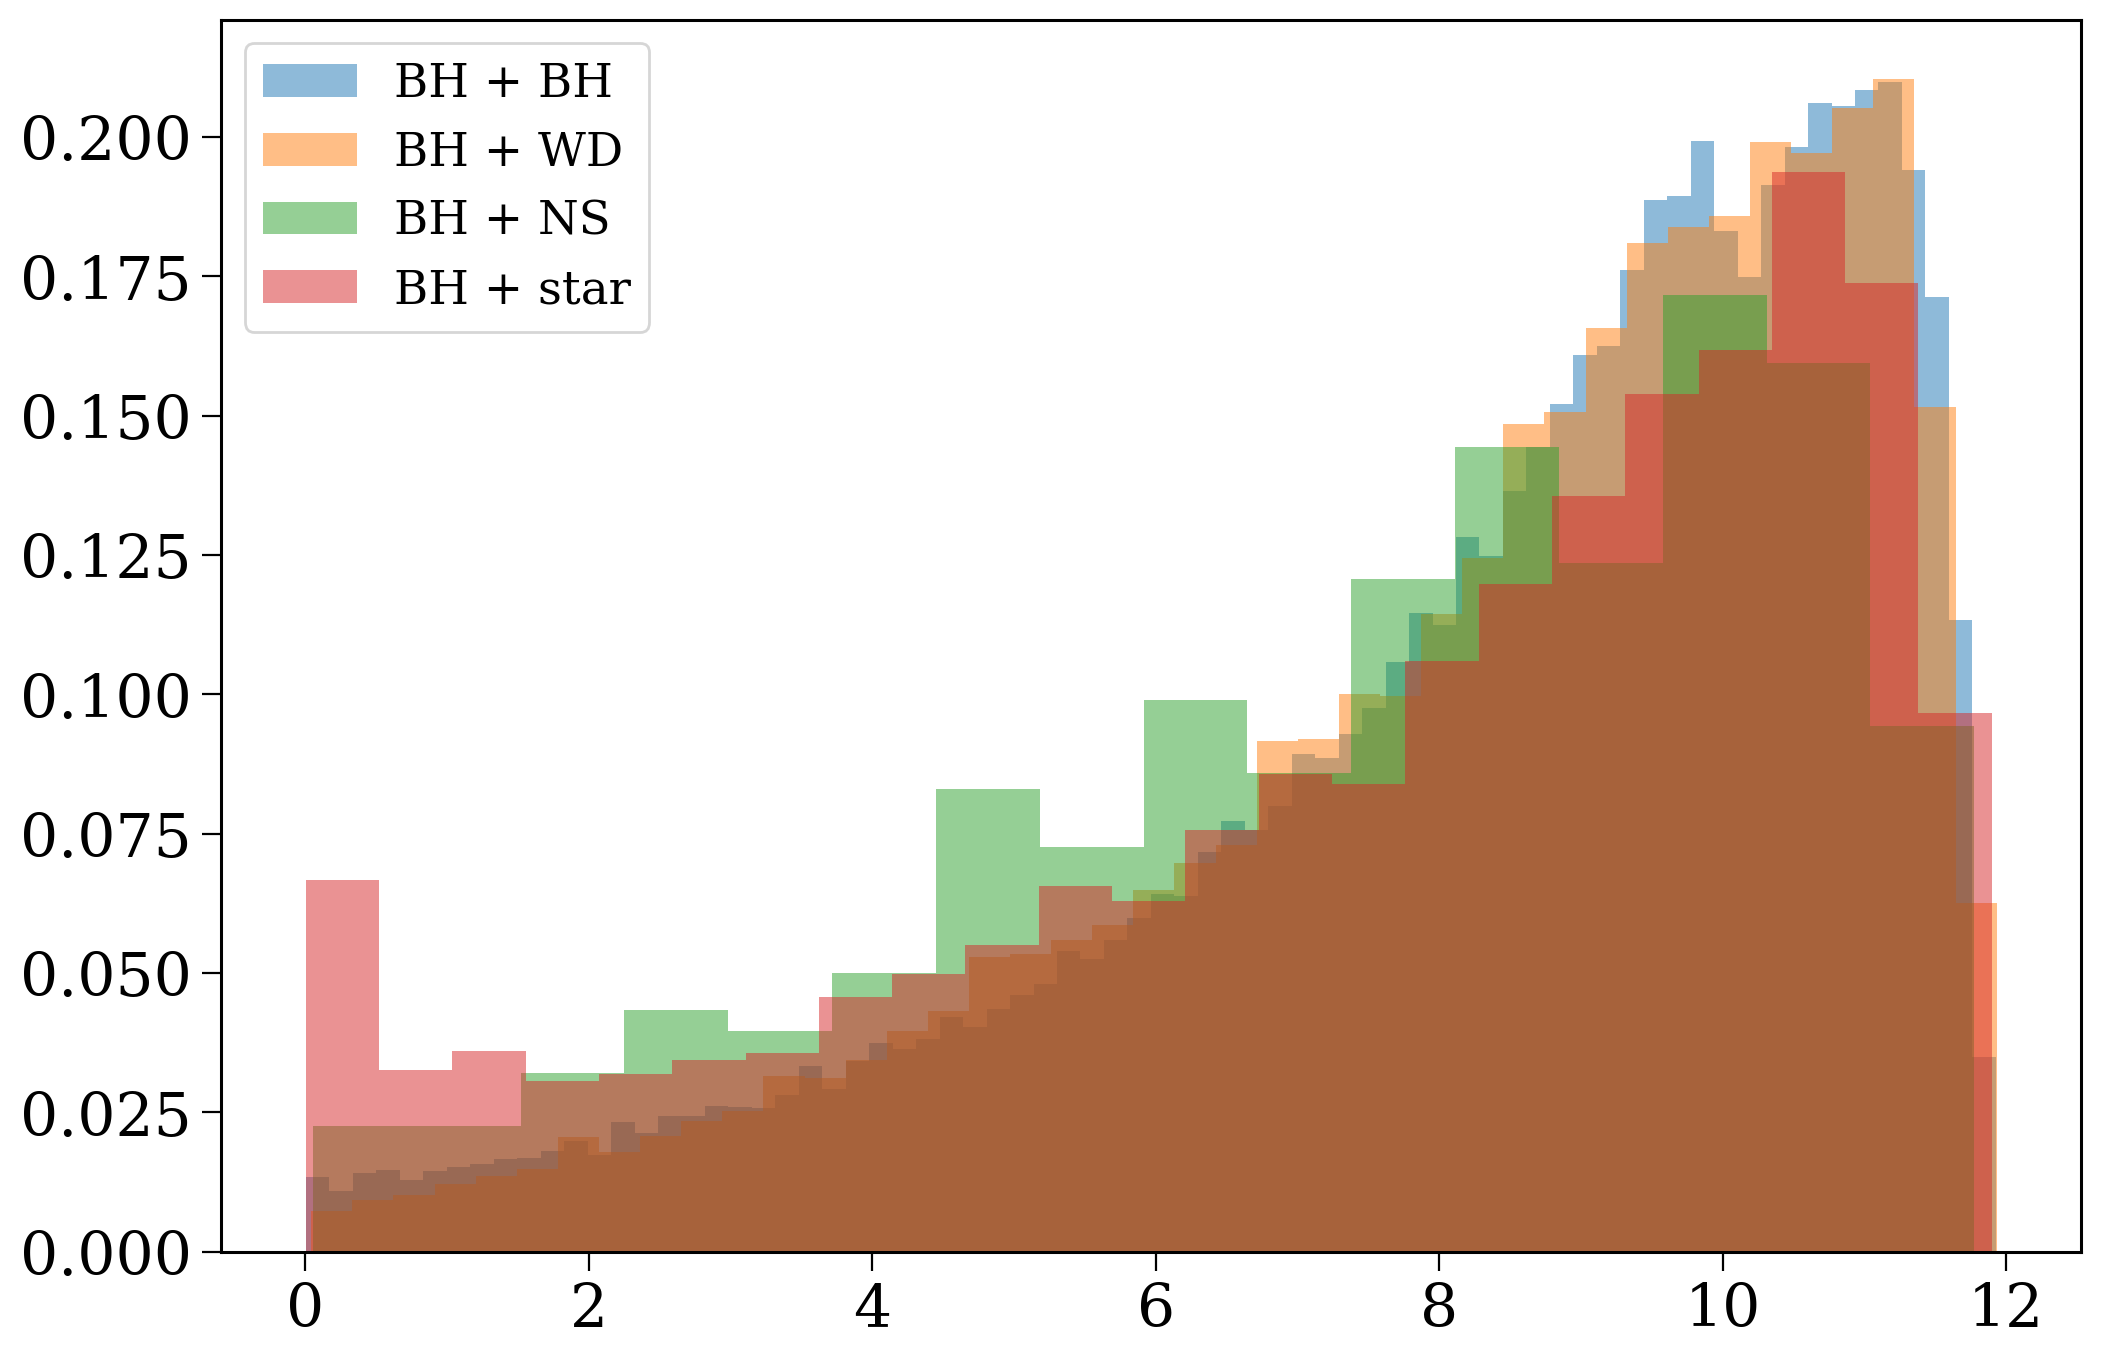

In [22]:
plt.hist(data["Fiducial"]["tau"]["BH"][bh_bh], bins="auto", alpha=0.5, density=True, label="BH + BH");
plt.hist(data["Fiducial"]["tau"]["BH"][bh_wd], bins="auto", alpha=0.5, density=True, label="BH + WD");
plt.hist(data["Fiducial"]["tau"]["BH"][bh_ns], bins="auto", alpha=0.5, density=True, label="BH + NS");
plt.hist(bh_star_pop.initial_galaxy.tau, bins="auto", alpha=0.5, density=True, label="BH + star")
plt.legend()
plt.show()

<Population - 5162 evolved systems - galactic_potential=MilkyWayPotential, sfh_model=CompositeStarFormationHistory>